<h1 style="color: RGB(27, 169, 127); font-size: 50pt";>PAP 2 – Python-Auswertung</h1>

## Wichtige Funktionen für das PAP.

Dieses Dokument ist von mir (FEZ) selbstständig geschreiben und verfasst worden. Viele Funktionen sind von anderen übernommen und abgewandelt worden. An der Stelle ist insbesondere L. Hafner zu nenne. Da der Code in VS Code geschrieben wird, wird teilweise auf den MS Copilot (K.I. Modell) zurückgegriffen. Dieser wird unterstützend und nicht generierend benutzt. Ich entschuldige mit hiermit auch formal für das unglaublich schlimme Denglisch in den Kommentaren und der Dokumentation. 

Vorlage zum bestimmen aller im Praktikum benötigten Formel und intigriertem Latex Export für eine effizientere Nutzung.

Diese Version ist noch nicht aktiell. Daher führen viele Überschriften in Leere Kapitel. (Stand 07.03.2026)

 
----

# Inhaltsverzeichnis für den Papulator
* [Definition der Versuchsvariablen](#Definition-der-Versuchsvariablen)
* [Import aller genutzen Libaries](#Import-aller-genutzen-Libaries)
* [Funktionen der Fehlerrechnung](#Funktionen-der-Fehlerrechnung)
    * [Runden signifikanter Stellen](#Runden-signifikanter-Stellen)
    * [Gaussische Fehlerfortpflanzung](#Gaussische-Fehlerfortpflanzung)
    * [Berechnung von Messwert und Fehler](#Berechnung-von-Messwert-und-Fehler)
    * [Signifikante Standartabweichung zweier Messwerte](#Signifikante-Standartabweichung-zweier-Messwerte)

* [Messdatenimporte](#Messdatenimporte)
    * [Patterns](#Patterns)
    * [Import von Experimentdaten](#Import-von-Experimentdaten)

* [Latex Export](#Latex-Export)
    * [Export von Gleichungen](#Export-von-Gleichungen)
    * [Export von Einzelergebnissen](#Export-von-Einzelergebnissen)
    * [Export von Messreihen (Tabelle)](#Export-von-Messreihen-(Tabelle))

+ [Calc_Everything](#Calc_Everything)

* [Plotting](#Plotting)

* [Ergebnisse der Aufgaben](#Ergebnisse-der-Aufgaben)


---
---

# Definition der Versuchsvariablen

Im Folgenden sind Versuchsvariablen definiert, die für einen besseren Workflow sorgen sollen. Diese werden zum exportieren und überschreiben von Dateien wichtig sein und ermöglichen es, diese Datei für jeden Versuch zu benutzen und lediglich die Variablen zu verändern. Es ist jedoch empfohlen eine Kopie der Forlage für jeden Versuch zu machen, damit dieses Dokument strukturiert bleibt.

Zudem sind wichtige Konstanten definiert, die immer wieder auftauchen.

In [213]:
versuchsnummer = "234"
versuchsname = "Lichtquellen"
aufgabe = "0z"

# Wichtige Konstanten
# Heidelberger Ortsgravitationsbeschleunigung in m/s^2
g_hd = 9.80984
err_g_hd = 0.00002

# Farben in hex
gruen="#1b722f"
hellgruen = "#1ba97f"
rot = "#b92d3a"
weinrot="#721c24"
blau="#073984"
lila = "#6610f2"


# Import aller genutzen Libaries

In [ ]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.stats import chi2
from scipy.stats import poisson
from scipy import signal
from scipy.signal import find_peaks, find_peaks_cwt
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial
from scipy.integrate import quad
from scipy.interpolate import interp1d

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms
import matplotlib.patches as patches
from adjustText import adjust_text
import string

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path

import pandas as pd # Auch wichtig für den Latex Export 
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

---
---
# Funktionen der Fehlerrechnung
Folglich werden eigene Funktionen definiert, die das Auswerten von Versuchen enorm vereinfachen sollen. Diese sind in vielen Punkten an fremden Code orientiert. 

## Runden signifikanter Stellen

In [215]:
def round_sig_digs(val, errVal):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
    ----------
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
    ------
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """

    # Daten zu Dezimal wechseln, da Floats probleme machen
    val = Decimal(str(val))
    errVal = Decimal(str(errVal))

    exp = int(math.floor(math.log10(float(errVal))))

    if round(float(errVal / (Decimal(10) ** exp))) < 3:
        exp -= 1

    scale = Decimal(10) ** exp

    val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale
    err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale

    # Exponent des Messwerts bestimmen
    if val_round != 0:
        val_exp = int(math.floor(math.log10(abs(float(val_round)))))
    else:
        val_exp = 0

    # wissenschaftliche Schreibweise, Werte auf selben Exponenten
    if val_exp <= -1:
        scale = Decimal(10) ** val_exp
        v = (val_round / scale)
        e = (err_round / scale)
        digits = -exp + val_exp
        res = f"({v:.{digits}f} \\pm {e:.{digits}f}) e{val_exp}"
    else:
        if exp > 0:
            res = f"{val_round} \\pm {err_round}"
        else:
            digits = -exp
            res = f"{(val_round):.{digits}g} \\pm {(err_round):.{digits}g}"
    return val_round, err_round, res

## Gaussische Fehlerfortpflanzung

In [216]:
def gff(func, errPronePar):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
    ----------
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
    ----------
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamters = []
    for errPar in errPronePar:
        d = sp.symbols('thisWillTurnDelta' + errPar.name)
        partial = sp.diff(func, errPar) * d  # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        error = error + partial**2 # Fehler werden quadratisch aufsummiert
        errProneParamters.append((errPar,d))
    absolut_err=sp.simplify(sp.sqrt(error),rational = True)             
    relativ_err=sp.simplify(sp.sqrt(error/func**2),rational = True)

    # Debugging Print
    # print(f"Die Fehlerfunktion zur Ausgangsfunktion {func} wurde erfolgreich nach den Fehlergrößen {errPronePar} bestimmt.")

    return absolut_err, relativ_err, errProneParamters

## Berechnung von Messwert und Fehler

In [217]:
def calc_with_err(func, errFunc, values):
    """
    Methode zum berechnen von Werten und deren Fehler.

    Parameter
    ----------
    **func** : sympy function
         Funktionen mit Parametern. 

    **errFunc** : sympy function
        Die zu func gehörende Fehlerformel. Wird über gff bestimmt.

    **values** : 
        Werte, die in die Funktionen eingesetzt werden.
        Als array von Tupeln der Form [(a,da),(b,db),...] oder als array/liste [a,da,b,db,...] 
        (Reihenfolge muss die sein, in der die Argumente in der Funktion genommen werden)

    Return
    ----------

    """

    #Falls der Input in mehrere Tupel aufgeteilt ist, werden diese zu einem Array zusammengefügt 
    if (np.ndim(values) != 1):                    
        values = np.concatenate(values)
    result = func(*values[::2])
    uncertainty = errFunc(*values)

    # Debigging Print
    # print(f"Die Ergebnisse wurden erfolgreich durch Funktion und Fehlerfunktion bestimmt!")

    return result, uncertainty

## Signifikante Standartabweichung zweier Messwerte

In [439]:
def sigma_abweichung(p1, p2, err_p1 = 0.0, err_p2 = 0.0):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    return round(abs(p1 - p2)/(np.sqrt(err_p1**2 + err_p2**2)), 2)

    if err_p1 == 0 and err_p2== 0:
        print("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung = abs(p1 - p2)/(np.sqrt(err_p1**2 + err_p2**2))
        # return abweichung
        return abs(p1 - p2)/(np.sqrt(err_p1**2 + err_p2**2))

---
---

# Messdatenimporte

Für die Auswertung von Versuchen ist es nicht selten, dass Messwerte in _CSV_ oder in _TXT_ Dateien gespeichert sind. Daher sollen diese Vernünftig eingelesen und verarbeitet werden, um das Benutzen der Daten möglichst einfach und instuinktiv zu gestalten. 

Um das Handeln von CSV Tabellen möglichst einfach zu gestalten, werden RIGEX-Pattern genutzt. Das heißt, wenn die Tabelle vor einem Versuch ordentlich strukturiert ist, können die Werte sofort genutzt werden, so wie es gewünscht ist. Dabei sollen folgende Eigenschaften erfüllt sein:
* Das Nutzen einer Kopfzeile ist nicht nur möglich, sondern explizit empfohlen. 
* Erkennung eines Messwertes, seiner Einheit und einer Potenz. Das hat dan bspw. die Form: _(name [unit] 10^{power})_
* Der zum Messwert gehörende Fehler. Dies ist meist ein Ablese Fehler. Die Bennenung sollte dabei: _err name_ sein. 
* Direkte Auswerten von Messreihen. Soll bspw. über mehrere Werte gemittelt werden, so wird automatisiert Mittelwert, Standartabweichung und gesamt Fehler der Messreihe bestimmt. 
* Dimensionslose Größen sollen erkannt werden. 
* Einstellung eines Indexes. Dies kann entweder die nummerische Angabe des Messdurchganges sein, oder der Parameter-Name. Wird bspw. dieselbe Messung in Wasser und in Luft durchgeführt, so sollen dies die Parameter-Namen sein. Diese sollen in der ersten Spalte der Tabelle stehen. 

## Patterns

In [219]:
# RegEx Patterns, um autoamtisiert Schemata anzuwenden und Daten anhand dieser auszuwerten. 

# Finden eines Messwertes, seiner Einheit und seiner Potenz
pattern = re.compile(
        r'^\s*'
        r'(?P<name>[^\[]+?)'    # alles bis zur ersten '['      # Name
        r'\s*\[\s*'             # echtes '['
        r'(?P<unit>[^\]]+?)'    # alles bis zur ']'             # Einheit
        r'\s*\]'                # echtes ']'
        r'(?:\s*10\^(?P<power>-?\d+))?'                         # optionale 10^n   
        r'\s*$'
    )

series_pattern = series_pattern = re.compile(
        r'^(?P<base>\w+)_\d+'
        r'(?:\s*\[\s*(?P<unit>[^\]]+)\s*\])?'
    )

# Index Spalte idx
index_pattern = re.compile(
    r'idx\s*'
    )

# Spalte die Ignoriert werden sill ign
ignore_pattern = re.compile(
    r'(?:ign[^,]*\s*,\s*)?'
)

# Messwert mit Einheit
messurment_pattern = re.compile(
    r'(?P<value>Messwert)\s*$$(?P<unit>[^$$]+)\]\s*,\s*'
)

# Fehler des Messwertes
error_pattern = re.compile(
    r'(?:err\s+Messwert\s*,\s*)?'
)

## Import von Experimentdaten

Das einlesen von Messweerten und das speichern dieser als Arrays für einen besseren zugriff. Automatisches herausfinden von Messwert und dazugehörigem Fehler.

In [220]:
def import_experimental_data(path:str = versuchsnummer + ".csv", setDelimiter:str = ",", setHeader:int = 0, setIndex_col:int = None):
    """
    
    Parameter
    ---------
    **path**: str
        Relatives verzeichnes der einzulesenden Datei. Am besten CSV-Datei einfach unter *versuchsnummer.csv* im Python-Folder speichern.

    **setDelimiter**: str
        Default ist hier das Komma:  > , <

    **setHeader**: int
        Setzt fest, was die Header-Row ist. Default ist 0 (die oberste Row) 

    Return
    ---------
    **cleanded** : Pandas DataFrame
        DataFrame, welches sicher zum weiterverwenden ist. NaN und ähnliches werden herausgefiltert und per Print
    """

    # Liest die Daten unmaipuliert
    try:
        df = pd.read_csv(path, delimiter=setDelimiter, header=0, index_col=None)
    except FileNotFoundError:
        print(f"The file {path} was not found.")
     
    # Wir erwarten nicht, dass zwei perfekt identische Zeilen existieren koennten, daher werden alle identischen Zeilen geloescht. Somit werden auch alle NaN Zeilen entfernt    
    # Langfristig soll das noch verschönert werden und wirklich nur NaN Zeilen gelöscht werden
    no_NaN_data = df.drop_duplicates(keep= False)
    df.reset_index(drop=True, inplace=True)

    return no_NaN_data 

# Speichert direkt das DataFrame als Variable, so kann dieses direkt in anderen Cells benutzt werden.
# experimental_data = import_experimental_data()


---
---

# Latex Export

### Erstellen der dedizierten Dartei zum Speichern der Werte für **LATEXT**

Folgender Code sollte einmal ausgeführt werden, damit direkt die Datei zum Speichern erstellt werden kann. Unbedingt daran denken, die Versuchsnummer anzupassen, die Werte anderer Versuche könnten ansonsten verloren gehen. Es gibt jedoch eine sicherheits Kopie. 

Die File wird Folgendes beinhalten:
* Formel, sowie Formel nach gff
* Berechnete Werte und deren Fehler
    * Wert + Fehler
    * Tabellen Export

In [221]:
def create_tex_result_file(fileName:str = f"python-results.sty", relativePath:str="../Auswertung/"):
    """
    Diese Method erstellt automatisch eine tex-Datei, in dem Messwerte bzw. deren Ergebnisse, Tabellen weiteres als variable gespeichert werden, die hier in diesem Python-code bestimmt werden.
    Die File wird unter *Versuche/${versuchsnummer}$/Auswertung/python-results.tex* zufinden sein. Am einfachsten ist es jedoch die Parameter frei zuhalten, da ansonsten auch das Verzeichnis in der *main.tex* 
    angepasst werden muss. 

    Die Python-File muss im Python-Ordner des jeweiligen Versuches liegen!

    Parameter
    ----------
    **fileName** : 
        neuer Name, falls die Datei besonders heißen soll.

    Return
    --------
    **path** : str
        Gibt den Path zur file wieder, welche autoamtisch generiert. In diese sollen später die Formeln geschrieben werden.
    """

    path = relativePath + fileName

    if os.path.isfile(path):
        print(f"{fileName} existiert bereits.")
        pass
    else:
        print(f"{fileName} wird in {relativePath} erzeugt.")
        with open(path, 'w') as file:
            file.write("% Dies ist eine automatisch generierte Datei. Hier werden automatisiert Variablen fuer Formeln, Ergebnisse und Tabellen erstellt. \n% Bitte nicht in diese Datei schreiben. Informationen koennten geloescht oder nicht richtig verarbeitet werden. \n\n%  _          _   _       _______      \n% | |        | | ( )     |__   __|\n% | |     ___| |_|/ ___     | | _____  __\n% | |    / _ \\__| / __|    | |/ _ \\/ /\n% | |___|  __/ |_  \\__ \\   | |  __/>  < \n% |______\\___|\\__| |___/    |_|\\___/_/\\_\\\n\n\n") 

        with open(path + "-BackUp.sty", 'w') as bFile:
            bFile.write("% Dies ist eine automatisch generierte Datei. Hier wird dediziert ein Back-Up erstellt, damit Werte nicht verloren gehen. \n\n%  _          _   _       _______      \n% | |        | | ( )     |__   __|\n% | |     ___| |_|/ ___     | | _____  __\n% | |    / _ \\__| / __|    | |/ _ \\/ /\n% | |___|  __/ |_  \\__ \\   | |  __/>  < \n% |______\\___|\\__| |___/    |_|\\___/_/\\_\\\n\n\n") 

    return path

# pyPath ist die File, in die der Latex Export geschehen soll.
pyPath = create_tex_result_file()

python-results.sty existiert bereits.


## Export von Gleichungen

In [222]:
def function_to_latex(func):
    # , texVarName:str, texCom:str
    """
    Zeigt die Formel als gerenderte Math-Darstellung und darunter
    den Latex-Quelltext, der per Button kopiert werden kann. (Für leichtere Benutzung als HTML).
    
    Zudem wird die Latexformel als Variable in Latex gespeichert.

    Parameters
    ----------
    **f** : sympy function

    **texVarName** : str
        Einzigartiger Name der Variablen. Dieser wird zum überschreiben alter Formel gebraucht.

    **texCom** : str
        setzt den newcommand-Kürzel für latex fest. Setzte kein Backslash! Auch texCom muss einzigartig gesetzt werden.
    """
    # print("Die gegebene Funktion lautet: \n")
    display(Math(sp.latex(func, long_frac_ratio=2).replace('thisWillTurnDelta', r'\Delta ')))

    print("Hier ist der dazugehörige Latex code: \n")
    latex_str = sp.latex(func, long_frac_ratio=2).replace('thisWillTurnDelta', r'\Delta ')
    html = f"""
    <div style="margin-top:0.5em;">
        <code id="latex-code-{id(func)}">
            {latex_str}
        </code>
        <button onclick="
            const tex_as_txt = document.getElementById('latex-code-{id(func)}').innerText;
            navigator.clipboard.writeText(tex_as_txt)
        " style="
            margin-left:8px;
            padding:2px 6px;
            cursor:pointer;
        ">
            Kopieren
        </button>
    </div>
    """
    display(HTML(html))


    # # Hinzufuegen bzw. Ueberschreieben der Formel in die Sammlung
    # with open(pyPath, 'r') as file:
    #     lines = file.readlines()
    # found = False

    # with open(pyPath, 'r') as file:
    #     for lineNum,  line in enumerate(lines, 1):
    #         if texVarName in line: # Checkt, ob der Variablen Name bereits vergeben ist.
    #             lines[lineNum] = "\\newcommand{\\" + texCom + "}{" + latex_str + "} \n\n"
    #             found = True
    #             # Deugging print
    #             # print(f'{texVarName} is at line {lineNum}') 

    # if not found:
    #     print("Die neue Funktion wurde hinzugefügt")
    #     with open(pyPath, 'w') as file:
    #         file.writelines(lines) # Schreibt den alten Stand
    #         file.write("\n\n% " + texVarName + "\n") # Fügt die Variable als Kommentar hinzu
    #         file.write("\\newcommand{\\" + texCom + "}{" + latex_str + "} \n\n")
    # else:
    #     print("Die alte Funktion wurde erfolgreich überschrieben.")
    #     with open(pyPath, 'w') as file:
    #         file.writelines(lines)

## Export von Einzelergebnissen

## Export von Messreihen (Tabelle)

In [223]:
def table_to_latex(df_tex: str, texVarName: str, texCom: str):
    """
    Fügt aus einem DataFrame entstandene Latex Tabelle der special Python File hinzu.

    Parameters
    ----------
    **df_tex** : pd.DataFrame.to_latex
        Uebersetztes DataFrame. Kann Label und Caption handlen. Dezimaltrennung steht auf ','.

    **texVarName** : str
        Einzigartiger Name der Variablen. Dieser wird zum überschreiben alter Formel gebraucht.

    **texCom** : str
        setzt den newcommand-Kürzel für latex fest. Setzte kein Backslash! Auch texCom muss einzigartig gesetzt werden.

    Returns
    -------
    Schreibt automatisch in die sty file
    """
    
    # Hinzufuegen bzw. Ueberschreieben der Tabelle in die Sammlung
    with open(pyPath, 'r') as file:
        lines: List[str] = file.readlines()
    found = False

    with open(pyPath, 'r') as file:
        for lineNum,  line in enumerate(lines):
            if texVarName in line: # Checkt, ob der Variablen Name bereits vergeben ist.
                print(f'{texVarName} starts at line {lineNum + 1}') 
                found = True
                table_start_line = lineNum
                break

    if not found:
        print(f"Die neue Tabelle ({texVarName}) wurde hinzugefügt")
        with open(pyPath, 'w') as file:
            file.writelines(lines) # Schreibt den alten Stand
            file.write("\n% " + texVarName + "\n")
            file.write("\\newcommand{\\" + texCom + "}{" + df_tex + "}\n\n")
    else:
        print(f"Die alte Tabelle ({texVarName}) wird überschrieben.")
        start_table = table_start_line + 1
        while start_table < len(lines) and lines[start_table].strip() == "":
            # Leere Zeile überspringen – das ist unser Marker
            start_table += 1
            break   # Wir wollen nur die erste leere Zeile

        # Falls kein leerer Marker gefunden wurde, gehen wir davon aus,
        # dass die Tabelle direkt in der nächsten Zeile startet.
        if start_table >= len(lines):
            start_table = table_start_line + 1

        end_table = start_table

        while end_table < len(lines):
            cur = lines[end_table].strip()

            # Abbruchbedingungen:
            if (
                cur.startswith(r"\\newcommand")
                or cur.startswith(r"\\section")
                or cur.startswith(r"\\subsection")
                or cur.startswith(r"\\begin")
            ):
                break

            end_table += 1

        if end_table > start_table:
            del lines[start_table - 1:end_table]

        insertion_point = table_start_line + 1  # Direkt nach der Zeile mit texVarName
        new_block = [
            # "\n\n",
            f"% {texVarName}\n",
            f"\\newcommand{{\\{texCom}}}{{{df_tex}}}\n",
        ]
        lines[insertion_point:insertion_point] = new_block

        with open(pyPath, 'w') as file:
            file.writelines(lines)

### Finaler Export 

Für die Auswertung sollen Messwerte und Fehler in einer Zelle stehen. Dies tut *tab_merge_val_err* automatisiert.

In [224]:
def tab_merge_val_err(df: pd.DataFrame, show_series_values:bool=False, setTexTabCap: str="", setTexTabLab:str=""):
    """Sucht im DataFrame nach einem Asdruck:
        "<name> [<unit>] <power>"
    und dem dazugehörigem Fehlerausdruck:
        "err <name>".
    Erstellt ein neues DataFrame für den Latex-Export

    Parameters
    ----------
    **df* : pd.DataFrame
        Original data frame.

    **show_series_values** : bool
        Rather the table should show the experimental data or just its mean
        

    Returns
    -------
    pd.DataFrame
        Eine Kopie von ``df``.
    """

    # Kopiert das alte DataFrame
    df_tex = pd.DataFrame(index=df.index)


    def format_tex(row):
        val = row[col]
        err = row[err_col]
        # return f'({val} \\pm {err}) \\mathrm{{{header_unit}}}'
        val_r, err_r = round_sig_digs(err, val)
        return f'${val_r} \\pm {err_r}$'
    
    # ----------------------------
    # 1) Einzelmessungen
    # ----------------------------

    for col in df.columns:
        col_match = pattern.match(col)

        if not col_match:
            # No header that follows the expected schema – skip it
            # print(f'Skipping column {col!r}: not "<value> [<unit>] <power>"')
            continue

        # Extract the captured parts
        name = col_match.group('name').strip()
        unit = col_match.group('unit').strip()
        power = col_match.group("power")   
        # print(f'Found measurement column: name={name!r}, unit={unit!r}, power={power!r}')

        # Build the name of the error column that must exist
        err_col = f'err {name}'
        if err_col not in df.columns:
            # print(f'No error column "{err_col}" for measurement "{name}" - skipping')
            continue

        if power:
            header_unit = f"$\\mathrm{{{unit}}} \\cdot 10^{{{power}}}$"
        else:
            header_unit = f"$\\mathrm{{{unit}}}$"

        df_tex[f'{name} [{header_unit}]'] = df.apply(format_tex, axis=1)


    # ----------------------------
    # 2) Messreihen
    # ----------------------------
    grouped = {}

    for col in df.columns:
        series_match = series_pattern.match(col)
        if series_match:
            base = series_match.group("base")
            unit = series_match.group("unit")
            # power = col_match.group("power")
            grouped.setdefault(base, {"cols": [], "unit": unit})
            grouped[base]["cols"].append(col)


    # --- Berechnungen ---
    for base, info in grouped.items():
        cols = info["cols"]
        series_unit = info["unit"] or ""


        err_col = f"err {base}"
        if err_col not in df.columns:
            continue

        values = df[cols]

        if show_series_values == True:
            # Einzelwerte in DataFrame hinzufuegen
            for ind, col in enumerate(cols, start=1):
                df_tex[f'{base}_{ind} [{unit}]'] = df.apply(format_tex, axis=1)

        # Mittelwert
        mean = values.mean(axis=1)

        # Standardabweichung
        std = values.std(axis=1, ddof=1)

        # Fehler des Mittelwerts
        stat_err = std / np.sqrt(len(cols))

        # systematischer Fehler
        sys_err = df[err_col]

        # Gesamtfehler
        total_err = np.sqrt(stat_err**2 + sys_err**2)

        # if power:
        #     header_unit = f"\\mathrm{{{unit}}} \\cdot 10^{{{power}}}"
        # else:
        #     header_unit = f"\\mathrm{{{unit}}}"

        formatted = []

        for m, e in zip(mean, total_err):
            m_r, e_r = round_sig_digs(e, m)
            formatted.append(f"${m_r} \\pm {e_r}$")

        df_tex[f"$\\overline{{{base}}} [\\mathrm{{{series_unit}}}]$"] = formatted

    setTexTabCap="Dies ist die Caption der Tabelle"
    setTexTabLab="bspTab"

    table_to_latex(df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h", index=False), texVarName="Beispielhafet Tabelle", texCom="bspTab")

    print(df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h"))
    return df_tex.to_latex(decimal=',', caption=setTexTabCap, label=setTexTabLab, position="h")


# combine_value_error(clean_data)

### Berechnen neuer Spalten mit Fehler

Die folgende Funktion berechnet anhand einer gegebenen Formel und den gegebenen Parametern die Ergebnisse einer neuen Spalte mit Ihren Fehlern.

In [225]:
def add_column_by_formula(func, errProneParams, headerName:str, headerUnit:str, err_free_params = []):
    pass

---
---

# Calc_Everything

In [226]:
# Code by Luca Hanfer (leicht verändert)
def calc_everything(function, params, data, params_without_error=[], print_formula:bool=True):
    """
    Returned Berechneten Wert plus Fehler. Zudem werden die Formeln als Latex-Code ausgeworfen.

    Parameter
    ----------
    **function**: sympy Funktion mit Parametern. In diese werden die Messwerte eingesetzt.

    **params**: Parameter der Funktion. Diese werden als Array von Sympy-Symbolen gebraucht. Bspw. [x, y, z]

    **data**: 2D-Array mit den Messdaten, sodass die Zeilen die Form haben: [Parameter 1, Fehler Parameter 1, Parameter 2,...]
        Die Funktion wird zeilenweise angewandt. Wird kein Fehler für einen Parameter angenommen, kann diese Spalte entweder mit dem Wert 0 
        an die Funktion gegeben werden oder ganz weggelassen werden. Dann muss allerdings der betreffende Parameter bei params_without_error angegeben werden.

    **params_without_error**: Alle Parameter zu denen kein Fehler explizit in den Daten angegeben ist. Dieser wird auf 0 gesetzt und kommt dann
        auch nicht in der Latex Form der Fehlerformel vor

    """

    exp_data = np.zeros((data.shape[0],data.shape[1]+len(params_without_error)))
    i = 0      # läuft durch die Parameter
    j = 0      # läuft durch die expanded data
    z = 0      # läuft durch die eingegebene data, also die Messwerte und deren Fehler
    # Läuft durch jeden Parameter und seinen Fehler
    while (i < len(params)):
        # Checkt, ob der Parameter Fehlerbehaftet ist. Wenn, dann wird an j-ter Stelle des exp_data der z-te Parameter aus data einegfügt.
        if (params[i] in params_without_error):
            exp_data[:,j] = data[:,z]
            i = i + 1
            j = j + 2
            z = z + 1
        else:
            exp_data[:,j] = data[:,z]
            exp_data[:,j+1] = data[:,z+1]
            i = i + 1
            j = j + 2
            z = z + 2

    # Create variable that stores parameters that have no assigned uncertainty    
    params_with_error = []
    j = 0
    for n in np.arange(0,len(params)):
        if not (params[n] in params_without_error):
            params_with_error.append(params[n])
            j = j + 1
    
    # Get the given function and error function as numpy functions
    f = sp.lambdify(params, function, "numpy")
    absolut_err, relativ_err, parameters = gff(function,params) # Gauss Fehlerfortpflanzung
    err_abs = sp.lambdify(np.concatenate(parameters), absolut_err, "numpy")

    # Calculate the results for each row of data
    results = np.zeros((data.shape[0],2))
    for n in np.arange(0, data.shape[0]):
        results[n,:] = calc_with_err(f, err_abs, exp_data[n,:])
    
    if (len(results) < 10):
        print("Results:")
        print(results)

    # Substitutes 0 for the uncertainty of the parameters without error, so it doesnt show up in the Latex Code
    for p in params_without_error:
        absolut_err = absolut_err.subs('thisWillTurnDelta'+p.name,0)
    for p in params_without_error:
        relativ_err = relativ_err.subs('thisWillTurnDelta'+p.name,0)

    if print_formula:
        # Wiedergabe des Latex-Codes
        function = sp.simplify(function,symbols = params, rational= True)
        function = sp.separatevars(function)
        # print("gegebene Funktion:")
        function_to_latex(function)

        print("Formel des absoluten Fehlers der gegebenen Funktion:")
        function_to_latex(absolut_err)

        print("Formel des relativen Fehlers der gegebenen Funktion:")
        function_to_latex(relativ_err)

    return(results)


def calc2(function, params,data, params_without_error = [], p_latex:bool = True):
    length = 1
    for e in data:
        if(np.shape(np.array(e)) != ()):
            length = np.shape(np.array(e))[0]
            break
    data_2d = np.zeros((length,len(data)))
    for i in range (0,len(data)):
        data_2d[:,i] = data[i]
    return(calc_everything(function,params, data_2d,params_without_error = params_without_error, print_formula=p_latex))


---
---

# Plotting

---
---
# Ergebnisse der Aufgaben

# Aufgabe 1: Das Sonenspektrum

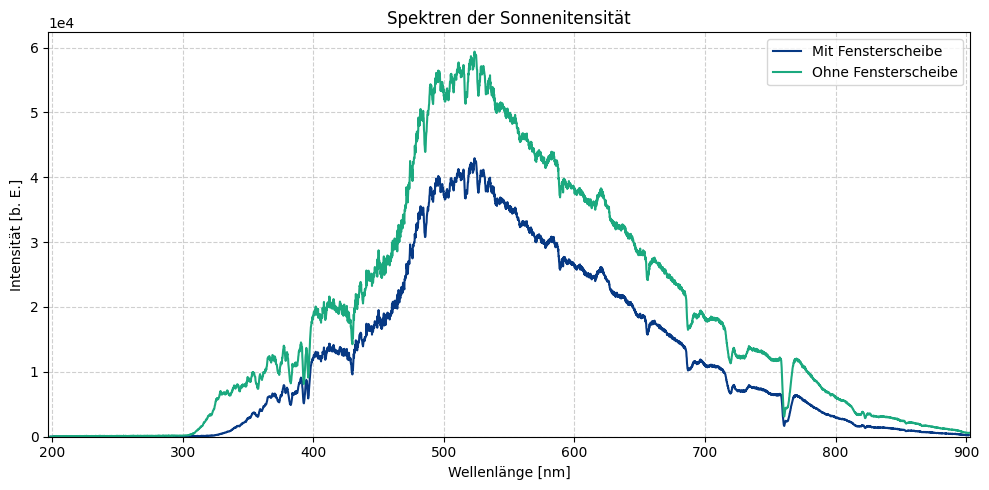

In [227]:
aufgabe = '1a' # Suffix für die Bennenung von Grafiken. Praktisch falsch kleine Manipulationen am Plot durchgeführt werde und beide gespeichert werden sollen.
folder = './A1/'
safe_folder = '../img/A1/'

# ---------------------------------------------------------------------
#   Einlesen der Textdateien des Sonnenspektrums
# ---------------------------------------------------------------------

# data = np.loadtxt(f'{folder}Geschlossen-Fenster.txt', skiprows=14, delimiter='\t', unpack=True)

ges_fenst = pd.read_csv(f'{folder}Geschlossen-Fenster.txt', sep="\t", decimal=",", skiprows=14)

offen_fenst = pd.read_csv(f'{folder}Offen-Fenster.txt', sep="\t", decimal=",", skiprows=14)

beide_fenst = pd.read_csv(f'{folder}Fenster-ueberlagert.txt', sep="\t", decimal=",", skiprows=14)


# ---------------------------------------------------------------------
#   Plotting der Sonnenspektren
# ---------------------------------------------------------------------

plt.figure(figsize=(10,5))

# Geschlossenes Fenster
plt.plot(
    ges_fenst.iloc[:,0], 
    ges_fenst.iloc[:,1], 
    label='Mit Fensterscheibe',
    color = blau
)

# Offenes Fenster
plt.plot(
    offen_fenst.iloc[:,0], 
    offen_fenst.iloc[:,1], 
    label='Ohne Fensterscheibe',
    color = hellgruen
)

plt.xlabel('Wellenlänge [nm]')
plt.ylabel('Intensität [b. E.]')
plt.title('Spektren der Sonnenitensität')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# plt.xlim(350, 800)

# Aufnahmebereich (Für alle Aufnahmen identisch)
plt.xlim(197, 903)
plt.ylim(-10, )

plt.ticklabel_format(axis='both', style='sci', scilimits=(0,4))

plt.tight_layout()

plt.savefig(f'{safe_folder}Vergleich_Sonnenspektren_{aufgabe}.pdf', dpi = 300)

plt.show()

0.21667569615325888
0.38331788558937036


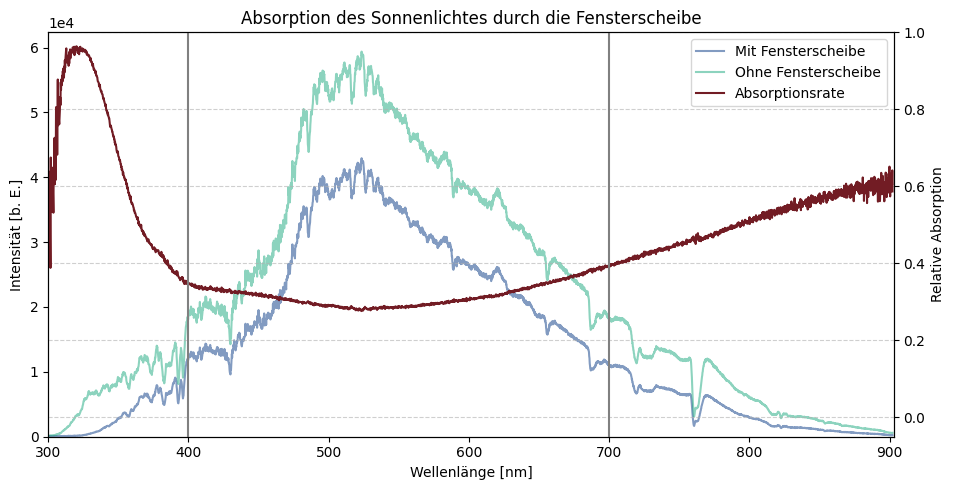

In [228]:
aufgabe = '1b' # Suffix für die Bennenung von Grafiken. Praktisch falsch kleine Manipulationen am Plot durchgeführt werde und beide gespeichert werden sollen.
folder = './A1/'
safe_folder = '../img/A1/'
# ---------------------------------------------------------------------
#   Prozentuale Abschwächng durch die scheibe
# ---------------------------------------------------------------------

proz_fenst_abw_int = 1 - np.array(ges_fenst) / np.array(offen_fenst)

print(np.mean(proz_fenst_abw_int))
print(np.std(proz_fenst_abw_int))


# ---------------------------------------------------------------------
#   Plot zur Absorption
# ---------------------------------------------------------------------
plt.figure(figsize=(10,5))


# Linke Achse
ax1 = plt.gca()

# Geschlossenes Fenster
ax1.plot(
    ges_fenst.iloc[:,0], 
    ges_fenst.iloc[:,1], 
    label='Mit Fensterscheibe',
    color=blau,
    alpha=0.5
)

# Offenes Fenster
ax1.plot(
    offen_fenst.iloc[:,0], 
    offen_fenst.iloc[:,1], 
    label='Ohne Fensterscheibe',
    color=hellgruen,
    alpha=0.5
)

ax1.set_xlabel('Wellenlänge [nm]')
ax1.set_ylabel('Intensität [b. E.]')
ax1.set_xlim(197, 903)
ax1.set_ylim(-10, )

# Absorption
proz_fenst_abw_int = 1 - ges_fenst.iloc[:,1] / offen_fenst.iloc[:,1]

ax2 = ax1.twinx()
ax2.plot(
    ges_fenst.iloc[:,0],
    proz_fenst_abw_int,
    label='Absorptionsrate',
    color=weinrot,
)

ax2.set_ylabel('Relative Absorption')
ax2.set_xlim(300, 903)
ax2.set_ylim(-0.05, 1)


lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

# Sichtbarer Bereich
plt.vlines(
    [400, 700],
    -1,
    1,
    color='grey',
    label='Sichtbarer Bereich'
)

plt.title('Absorption des Sonnenlichtes durch die Fensterscheibe')
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

ax1.ticklabel_format(axis='both', style='sci', scilimits=(0,4))

plt.savefig(f'{safe_folder}Abs_S_{aufgabe}.pdf', dpi=300)
plt.show()

## Frauenhofer Linien

In [229]:
# ---------------------------------------------------------------------
#   Bestimmen der Frauenhofer Linien
# ---------------------------------------------------------------------

theo_fl = {
    "$K$": 393.4,
    "$H$": 396.8,
    "$h / H_\\delta$": 410.2,     # H-delta
    "$G$": 430.8,
    "$G' / H_\\gamma$": 434.0,    # H-gamma
    "$F / H_\\beta$": 486.1,     # H-beta
    "$b_2$": 517.3,
    "$b_1$": 518.4,
    "$E$": 527.0,
    "$D_2$": 589.0,
    "$D_1$": 589.6,
    "$C / H_\\alpha$": 656.3,     # H-alpha
    "$B$": 686.7,
    "$A$": 759.4
}

# Linien wurden Händisch in Inkcscape eingezeichnet und mit dem Integrierten MessTool Vermessen
# Einheiten sind in mm angegeben

# Umrechnungsfaktor Wellenlänge/Inkscale 
ink_scale = (800-350) / 224.45 # Wellenlängenbereich des Plots

print(ink_scale)

# Das Tool hat die Differenzen zwischen den Messpunkten bestimt (in mm):
diff_fl_ink = np.array([21.38, 1.64, 6.53, 10.36, 1.89, 25.94, 15.33, 0.63, 4.34, 30.99, 0.19, 33.35, 15.52, 36.63]) # erster Wert ist Abstand von 350nm zur K-Linie (~393.4nm)


# Namen passend zu deinen Linien
names = ["K", "H", "h / H_\\delta", "G", "G' / H_\\gamma", "F / H_\\beta", "b2", "b1", "E", "D_2", "D_1", "C / H_\\alpha ", "B", "A"]
names_tex = ["$K$", "$H$", "$h / H_\\delta$", "$G$", "$G' / H_\\gamma$", "$F / H_\\beta$", "$b_2$", "$b_1$", "$E$", "$D_2$", "$D_1$", "$C / H_\\alpha$", "$B$", "$A$"]

# Ungenauigkeit geschätzt (in mm):
err_diff_fl_ink = 0.15

# absolute Positionen in mm
pos_ink = np.cumsum(diff_fl_ink)

lambda_exp = 350 + pos_ink * ink_scale
err_lambda_exp = err_diff_fl_ink * ink_scale
print(err_lambda_exp)

2.0049008687903767
0.3007351303185565


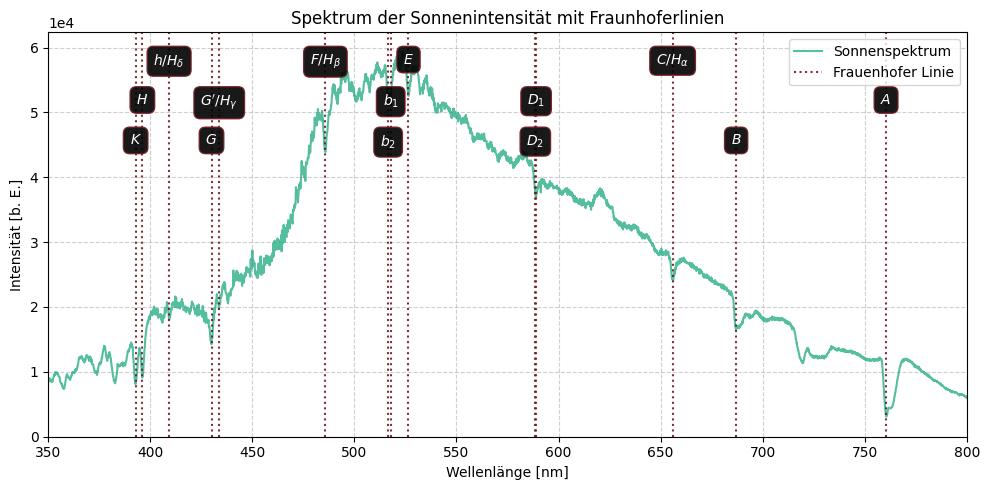

In [230]:
aufgabe = '1c'
folder = './A1/'
safe_folder = '../img/A1/'

# ---------------------------------------------------------------------
#   Plotting der Frauenhoferlinien
# ---------------------------------------------------------------------

plt.figure(figsize=(10,5))

# Offenes Fenster
plt.plot(
    offen_fenst.iloc[:,0], 
    offen_fenst.iloc[:,1], 
    label='Sonnenspektrum',
    color = hellgruen,
    alpha=0.75,
)

heights = [0.75, 0.85, 0.95]

# # Theoretische Fruaenhofer Linien
# for i, (name, wavelength) in enumerate(theo_fl.items()):
#     y_pos = plt.ylim()[1] * heights[i % len(heights)]

#     plt.axvline(
#         x=wavelength,
#         color='red',
#         linestyle=':',
#         alpha=0.9,
#         label='Frauenhofer Linie' if i == 0 else None
#     )

#     plt.text(
#         wavelength, 
#         y_pos, 
#         name,
#         # rotation=90,
#         color='white',
#         ha='center',
#         va='top',
#         fontsize=8,
#         bbox=dict(
#             boxstyle='round',
#             facecolor='black',
#             edgecolor=weinrot,
#             alpha=0.9,
#             pad=0.45
#         )
#     )

for i, (name, wavelength) in enumerate(zip(names_tex, lambda_exp)):
    y_pos = plt.ylim()[1] * heights[i % len(heights)]

    plt.axvline(
        x=wavelength,
        color=weinrot,
        linestyle=':',
        alpha=0.9,
        label='Frauenhofer Linie' if i == 0 else None
    )

    plt.text(
        wavelength,
        y_pos,
        name,
        # rotation=90,
        color='white',
        ha='center',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='black',
            edgecolor=weinrot,
            alpha=0.9,
            pad=0.45
        )
    )


plt.xlabel('Wellenlänge [nm]')
plt.ylabel('Intensität [b. E.]')
plt.title('Spektrum der Sonnenintensität mit Fraunhoferlinien')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

# plt.xlim(197, 903)
plt.xlim(350, 800)

plt.ylim(-10, )

plt.ticklabel_format(axis='both', style='sci', scilimits=(0,4))


plt.tight_layout()
plt.savefig(f'{safe_folder}FL_S_{aufgabe}.pdf', dpi=300)
plt.show()

In [231]:
# ---------------------------------------------------------------------
#   Signifikante Abweichung zum Literatur Wert und Latex Export
# ---------------------------------------------------------------------

# DataFrame erstellen
df = pd.DataFrame({
    "\\text{{Line}}": names_tex,
    "\\lambda_\\text{{theo}} [\\mathrm{{nm}}]": [theo_fl[n] for n in names_tex],
    "\\lambda_\\text{{exp}} [\\mathrm{{nm}}]": lambda_exp,
    "err_nm": [err_lambda_exp]*len(names_tex)
})

# Standard Abweichung berechnen
df["\\text{{Std. Abw. }} \\sigma"] = sigma_abweichung(df['\\lambda_\\text{{theo}} [\\mathrm{{nm}}]'], df['\\lambda_\\text{{exp}} [\\mathrm{{nm}}]'], 0, df['err_nm'])

df["\\lambda_\\text{{exp}} [\\mathrm{{nm}}]"] = df.apply(lambda row: f"{row['\\lambda_\\text{{exp}} [\\mathrm{{nm}}]']:.1f} \\pm {row['err_nm']:.1f}", axis=1)

# Tabelle für LaTeX formatieren
latex_table = df[["\\text{{Line}}", "\\lambda_\\text{{theo}} [\\mathrm{{nm}}]", "\\lambda_\\text{{exp}} [\\mathrm{{nm}}]", "\\text{{Std. Abw. }} \\sigma"]].to_latex(
    index=False,
    caption="Vergleich der theoretischen und experimentellen Frauenhofer-Linien",
    label="tab:fraunhofer",
    float_format="%.1f",
    column_format="L | C C || C"
)

print(latex_table)

\begin{table}
\caption{Vergleich der theoretischen und experimentellen Frauenhofer-Linien}
\label{tab:fraunhofer}
\begin{tabular}{L | C C || C}
\toprule
\text{{Line}} & \lambda_\text{{theo}} [\mathrm{{nm}}] & \lambda_\text{{exp}} [\mathrm{{nm}}] & \text{{Std. Abw. }} \sigma \\
\midrule
$K$ & 393.4 & 392.9 \pm 0.3 & 1.8 \\
$H$ & 396.8 & 396.2 \pm 0.3 & 2.2 \\
$h / H_\delta$ & 410.2 & 409.2 \pm 0.3 & 3.2 \\
$G$ & 430.8 & 430.0 \pm 0.3 & 2.6 \\
$G' / H_\gamma$ & 434.0 & 433.8 \pm 0.3 & 0.6 \\
$F / H_\beta$ & 486.1 & 485.8 \pm 0.3 & 1.0 \\
$b_2$ & 517.3 & 516.5 \pm 0.3 & 2.5 \\
$b_1$ & 518.4 & 517.8 \pm 0.3 & 2.0 \\
$E$ & 527.0 & 526.5 \pm 0.3 & 1.6 \\
$D_2$ & 589.0 & 588.6 \pm 0.3 & 1.2 \\
$D_1$ & 589.6 & 589.0 \pm 0.3 & 1.9 \\
$C / H_\alpha$ & 656.3 & 655.9 \pm 0.3 & 1.4 \\
$B$ & 686.7 & 687.0 \pm 0.3 & 1.0 \\
$A$ & 759.4 & 760.4 \pm 0.3 & 3.5 \\
\bottomrule
\end{tabular}
\end{table}



## Einschub; sind b_1 und b_2 bzw. D_1 und D_2 zu unterscheiden?

In [232]:
b_indices = [6, 7]   # b2, b1
D_indices = [9, 10]  # D2, D1

# Wellenlängen und Fehler
lambda_b = lambda_exp[b_indices]
err_b = err_lambda_exp

lambda_D = lambda_exp[D_indices]
err_D = err_lambda_exp

names_b = [names_tex[i] for i in b_indices]
names_D = [names_tex[i] for i in D_indices]

abw_b = sigma_abweichung(lambda_b[0], lambda_b[1], err_b, err_b)
print(abw_b)

abw_D = sigma_abweichung(lambda_D[0], lambda_D[1], err_D, err_D)
print(abw_D)

2.96984848098322
0.8956685895031474


In [233]:
def plot_lines_with_error(ax, wavelengths, names, err, y_min, y_max, color_line='red', color_err='red', b_label = False,  label='Messreihe'):
    for wl, name in zip(wavelengths, names):
        # Fehlerrechteck
        rect = patches.Rectangle(
            (wl - err, y_min),  # linke untere Ecke
            2 * err,            # Breite
            y_max - y_min,      # Höhe
            color=color_err,
            alpha=0.3
        )
        ax.add_patch(rect)

    # Linienmittellinie
    for i, wl in enumerate(wavelengths):
        ax.axvline(
            wl,
            color=color_line,
            linestyle=':',
            alpha=0.9,
            label=label if (b_label and i == 0) else None
        )

    # Text
    height_scale = [0.95, 0.85, 0.75, 0.65]
    for i, (wl, name) in enumerate(zip(wavelengths, names)):
        ax.text(
            wl,
            y_max * height_scale[i % len(height_scale)],
            name,
            color='black',
            ha='center',
            va='top',
            fontsize=10,
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                edgecolor=color_line,
                alpha=0.9,
                pad=0.45
            )
        )


        # texts = []

        # for wl, name in zip(wavelengths, names):
        #     texts.append(
        #         ax.text(wl, y_max * 0.95, name, ha='center', va='top')
        #     )

        # adjust_text(
        #     texts,
        #     ax=ax,
        #     only_move={'points': 'y', 'text': 'y'},
        #     arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
        # )


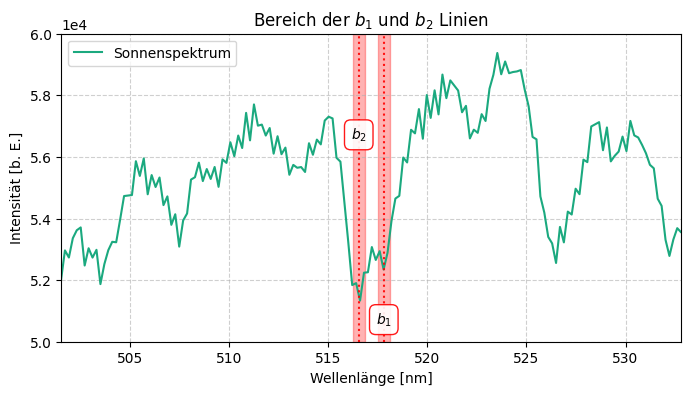

In [234]:
aufgabe = '1Z'
folder = './A1/'
safe_folder = '../img/A1/'
plt.figure(figsize=(8,4))
ax = plt.gca()

# Sonnenspektrum plotten
ax.plot(
    offen_fenst.iloc[:,0], 
    offen_fenst.iloc[:,1], 
    label='Sonnenspektrum',
    color=hellgruen
)

# Fehlerrechtecke und Linien
plot_lines_with_error(
    ax,
    lambda_b,
    names_b,
    err_b,
    y_min=50000,
    y_max=60000,
    b_label = False
)

ax.set_xlabel('Wellenlänge [nm]')
ax.set_ylabel('Intensität [b. E.]')
ax.set_title('Bereich der $b_1$ und $b_2$ Linien')
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(lambda_b.min() - 15, lambda_b.max() + 15)
ax.set_ylim(50000, 60000)

plt.legend()
plt.ticklabel_format(axis='both', style='sci', scilimits=(0,4))
plt.savefig(f'{safe_folder}bL_{aufgabe}.pdf', dpi=300)
plt.show()



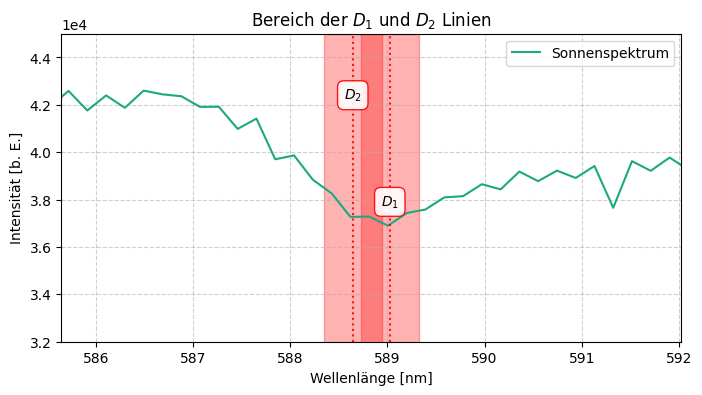

In [235]:
plt.figure(figsize=(8,4))
ax = plt.gca()

ax.plot(
    offen_fenst.iloc[:,0], 
    offen_fenst.iloc[:,1], 
    label='Sonnenspektrum',
    color=hellgruen
)

plot_lines_with_error(
    ax,
    lambda_D,
    names_D,
    err_D,
    y_min=0,
    y_max=45000
)

ax.set_xlabel('Wellenlänge [nm]')
ax.set_ylabel('Intensität [b. E.]')
ax.set_title('Bereich der $D_1$ und $D_2$ Linien')
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(lambda_D.min() - 3, lambda_D.max() + 3)
ax.set_ylim(32e3, 45e3)
plt.legend()

plt.ticklabel_format(axis='both', style='sci', scilimits=(0,4))
plt.savefig(f'{safe_folder}DL_{aufgabe}.pdf', dpi=300)
plt.show()

# Aufgabe 2) Künstliche Lichtquellen

In [236]:
# ---------------------------------------------------------------------
#   Einlesen der Messwerte
# ---------------------------------------------------------------------

aufgabe = '2a'
folder = './A2/LED_K/'
safe_folder = '../img/A2/'

# LED Kasten (7 LEDs)
LED_1 = pd.read_csv(f'{folder}LED-Kasten-1__WEISS-Warm.txt', sep="\t", decimal=",", skiprows=14)
LED_2 = pd.read_csv(f'{folder}LED-Kasten-2__WEISS-Kalt.txt', sep="\t", decimal=",", skiprows=14)
LED_3 = pd.read_csv(f'{folder}LED-Kasten-3__BLAU.txt', sep="\t", decimal=",", skiprows=14)
LED_4 = pd.read_csv(f'{folder}LED-Kasten-4__WEISS.txt', sep="\t", decimal=",", skiprows=14)
LED_5 = pd.read_csv(f'{folder}LED-Kasten-5__ORAGE.txt', sep="\t", decimal=",", skiprows=14)
LED_6 = pd.read_csv(f'{folder}LED-Kasten-6__GELB.txt', sep="\t", decimal=",", skiprows=14)
LED_7 = pd.read_csv(f'{folder}LED-Kasten-7__ROT.txt', sep="\t", decimal=",", skiprows=14)

folder = './A2/'
# Andere
e_spar = pd.read_csv(f'{folder}Energiesparlampe.txt', sep="\t", decimal=",", skiprows=14)
glue = pd.read_csv(f'{folder}Gluelampe.txt', sep="\t", decimal=",", skiprows=14)
laser = pd.read_csv(f'{folder}Laser.txt', sep="\t", decimal=",", skiprows=14)
LED_Hue = pd.read_csv(f'{folder}LED-Hue-RGB.txt', sep="\t", decimal=",", skiprows=14)
LED_lamp = pd.read_csv(f'{folder}LED-Lampe.txt', sep="\t", decimal=",", skiprows=14)

datasets = {
    "LED warmweiß": LED_1,
    "LED kaltweiß": LED_2,
    "LED blau": LED_3,
    "LED weiß": LED_4,
    "LED orange": LED_5,
    "LED gelb": LED_6,
    "LED rot": LED_7,
    "Energiesparlampe": e_spar,
    "Glühlampe": glue,
    "Laser": laser,
    "LED Hue RGB": LED_Hue,
    "LED Lampe": LED_lamp
}

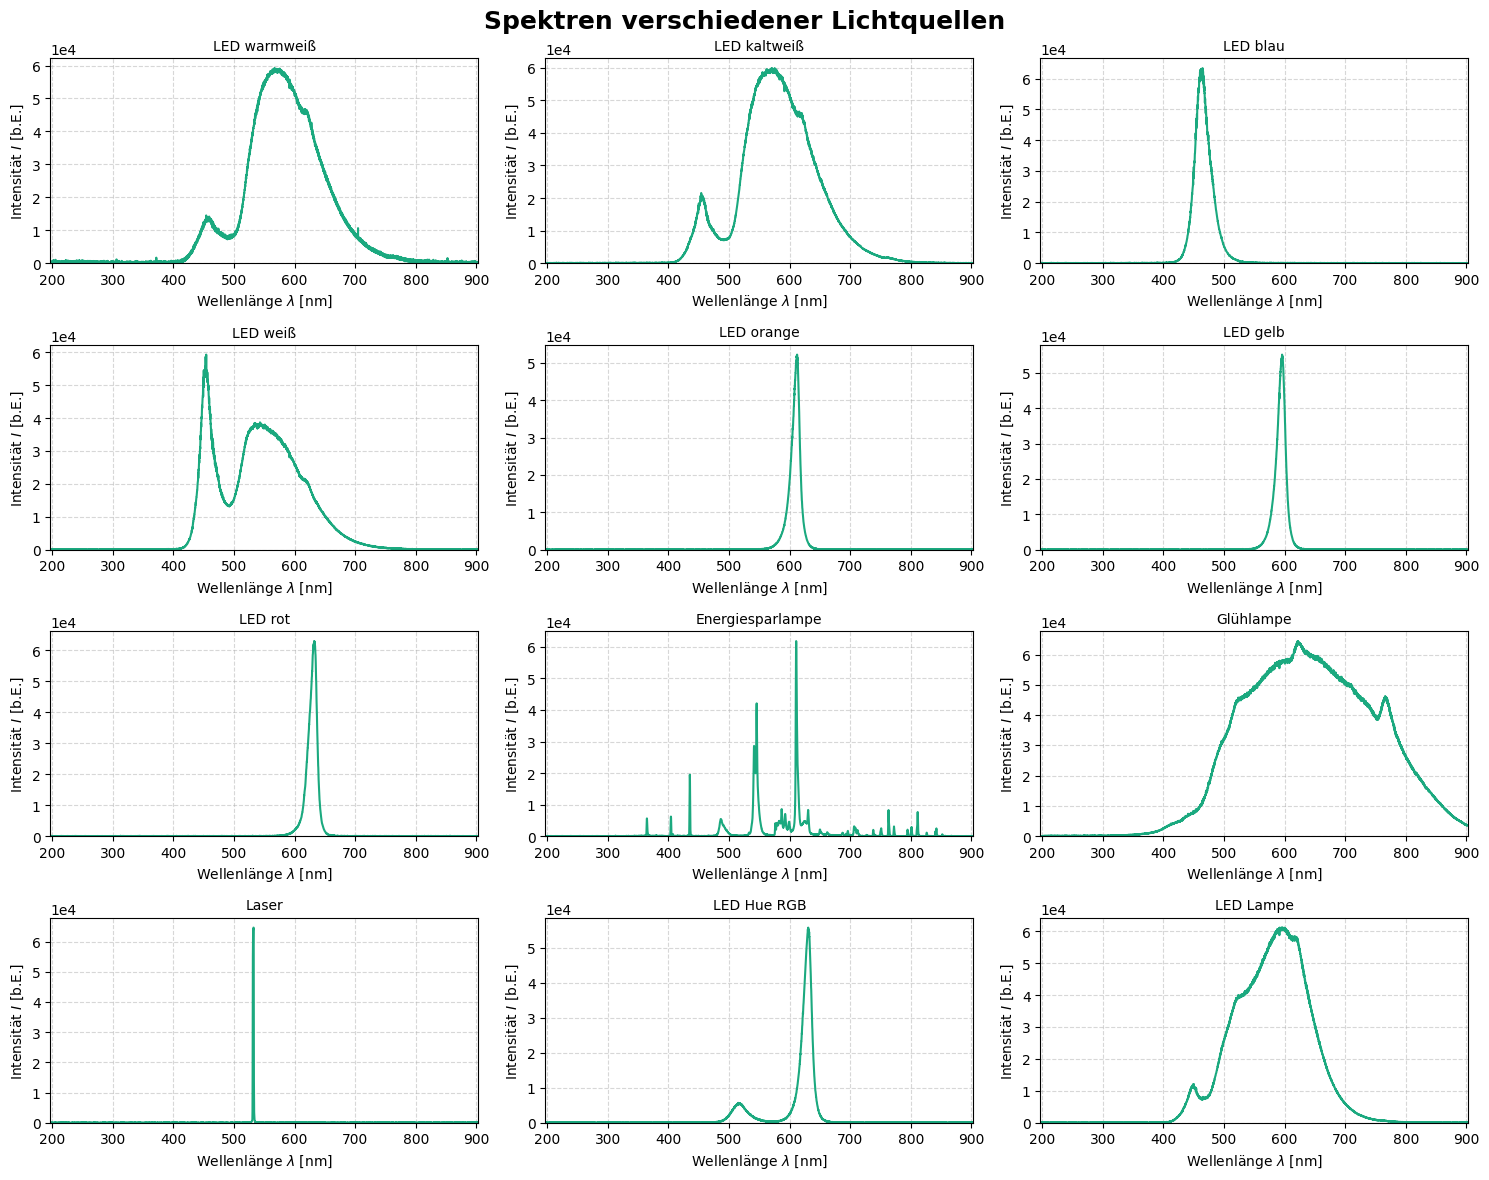

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (name, data) in enumerate(datasets.items()):
    ax = axes[i]
    
    ax.plot(
        data.iloc[:,0],   # Wellenlänge
        data.iloc[:,1],   # Intensität
        color=hellgruen
    )
    
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Wellenlänge $\\lambda$ [nm]")
    ax.set_ylabel("Intensität $I$ [b.E.]")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xlim(197, 903)
    ax.set_ylim(-10, )
    ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))


plt.suptitle("Spektren verschiedener Lichtquellen", fontsize=18, weight='bold')
plt.tight_layout()

plt.savefig(f"{safe_folder}Spektren_Grid.pdf", dpi=300)
plt.show()

In [238]:
# ---------------------------------------------------------------------
#   Bestimmung der mittleren Wellenlänge
# ---------------------------------------------------------------------
def avg_wavLength(df):
    lam = df.iloc[:,0]
    intensity = df.iloc[:,1]
    return np.sum(lam * intensity) / np.sum(intensity)

results = {}

for name, df in datasets.items():
    results[name] = avg_wavLength(df)

print(results)

df_results = pd.DataFrame(list(results.items()), columns=["Lichtquelle", "Mittlere Wellenlänge [nm]"])
latex_table = df_results.to_latex(
    index=False,
    float_format="%.2f",
    caption="Mittlere Wellenlängen verschiedener Lichtquellen",
    label="tab:wellenlaengen",
    column_format="l | c"
)
print(latex_table)

{'LED warmweiß': np.float64(586.0171038885152), 'LED kaltweiß': np.float64(582.2268966761512), 'LED blau': np.float64(466.8907114533283), 'LED weiß': np.float64(543.5878143331178), 'LED orange': np.float64(608.021267676806), 'LED gelb': np.float64(592.2666976081828), 'LED rot': np.float64(627.8545094039849), 'Energiesparlampe': np.float64(588.2701219172737), 'Glühlampe': np.float64(650.2645776015394), 'Laser': np.float64(532.1252623763552), 'LED Hue RGB': np.float64(611.6684894331376), 'LED Lampe': np.float64(580.9544348460508)}
\begin{table}
\caption{Mittlere Wellenlängen verschiedener Lichtquellen}
\label{tab:wellenlaengen}
\begin{tabular}{l | c}
\toprule
Lichtquelle & Mittlere Wellenlänge [nm] \\
\midrule
LED warmweiß & 586.02 \\
LED kaltweiß & 582.23 \\
LED blau & 466.89 \\
LED weiß & 543.59 \\
LED orange & 608.02 \\
LED gelb & 592.27 \\
LED rot & 627.85 \\
Energiesparlampe & 588.27 \\
Glühlampe & 650.26 \\
Laser & 532.13 \\
LED Hue RGB & 611.67 \\
LED Lampe & 580.95 \\
\bottomrule

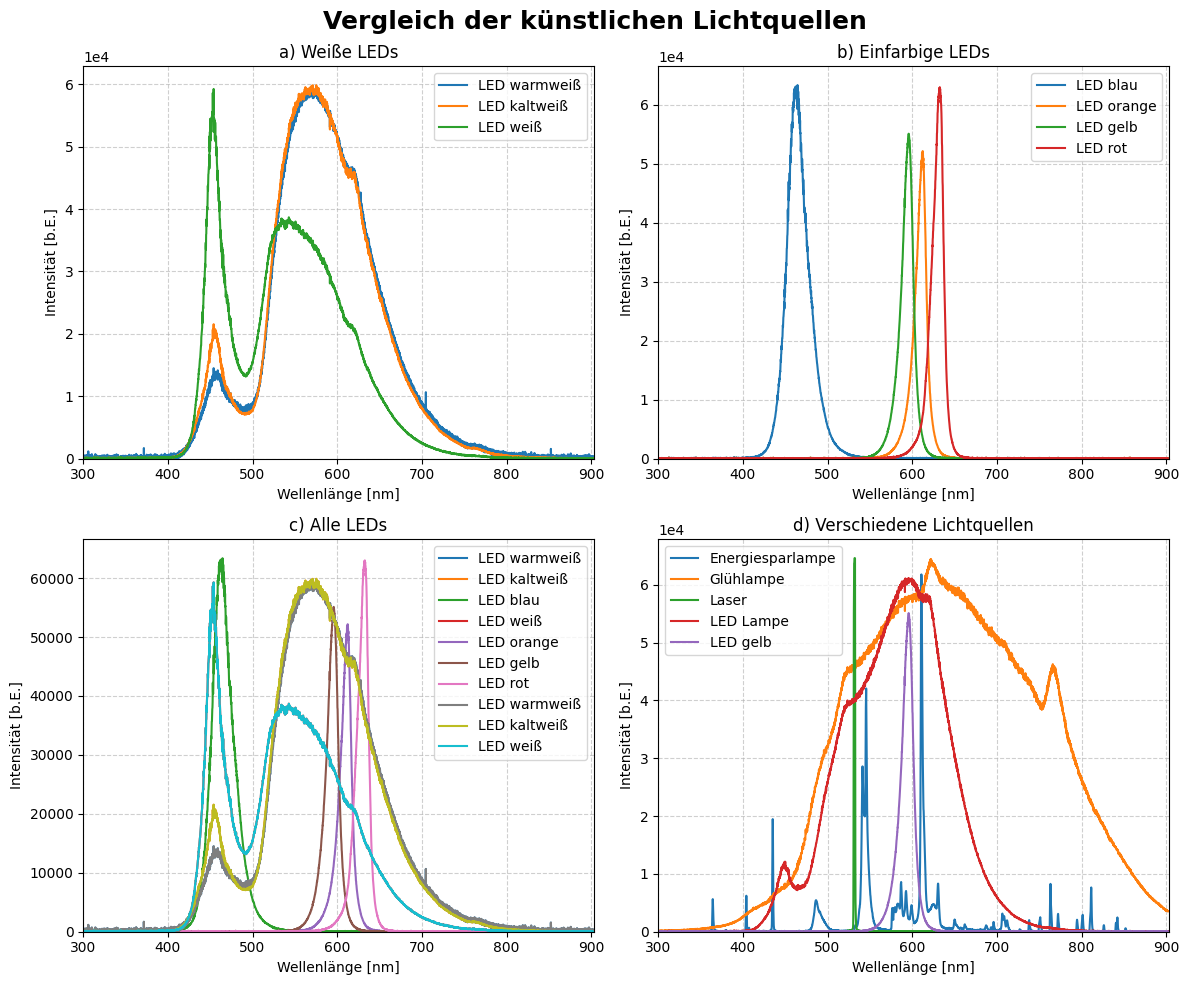

In [239]:
aufgabe = '2c'
folder = './A2/LED_K/'
safe_folder = '../img/A2/'

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

colored_led_keys = [
    "LED blau", "LED orange", "LED gelb", "LED rot"
]

white_led_keys = [
    "LED warmweiß", "LED kaltweiß", "LED weiß"
]

all_led_keys = [
    "LED warmweiß", "LED kaltweiß", "LED blau",
    "LED weiß", "LED orange", "LED gelb", "LED rot",
    "LED warmweiß", "LED kaltweiß", "LED weiß"
]

other_sources = [
    "Energiesparlampe", "Glühlampe", "Laser", "LED Lampe", "LED gelb"
]

# --------------------------------------------------
# c) Alle LEDs
# --------------------------------------------------
ax = axes[2]
for key in all_led_keys:
    df = datasets[key]
    ax.plot(df.iloc[:, 0], df.iloc[:, 1], label=key)

ax.set_title("c) Alle LEDs")
ax.set_xlabel("Wellenlänge [nm]")
ax.set_ylabel("Intensität [b.E.]")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(300, 903)
ax.set_ylim(-10, )

# --------------------------------------------------
# d) Verschiedene Lichtquellen
# --------------------------------------------------
ax = axes[3]
for key in other_sources:
    df = datasets[key]
    ax.plot(df.iloc[:, 0], df.iloc[:, 1], label=key)

ax.set_title("d) Verschiedene Lichtquellen")
ax.set_xlabel("Wellenlänge [nm]")
ax.set_ylabel("Intensität [b.E.]")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(300, 903)
ax.set_ylim(-10, )
ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))


# --------------------------------------------------
# a) Weiße LEDs
# --------------------------------------------------
ax = axes[0]
for key in white_led_keys:
    df = datasets[key]
    ax.plot(df.iloc[:, 0], df.iloc[:, 1], label=key)

ax.set_title("a) Weiße LEDs")
ax.set_xlabel("Wellenlänge [nm]")
ax.set_ylabel("Intensität [b.E.]")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(300, 903)
ax.set_ylim(-35, )
ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))


# --------------------------------------------------
# b) Farbige LED 
# --------------------------------------------------
ax = axes[1]
for i, key in enumerate(colored_led_keys, start=1):
    df = datasets[key]
    ax.plot(df.iloc[:, 0], df.iloc[:, 1], label=f"{key}")

ax.set_title("b) Einfarbige LEDs")
ax.set_xlabel("Wellenlänge [nm]")
ax.set_ylabel("Intensität [b.E.]")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(300, 903)
ax.set_ylim(-35, )
ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))


plt.suptitle('Vergleich der künstlichen Lichtquellen', size = 18, weight = 'bold')
plt.tight_layout()
plt.savefig(f'{safe_folder}Vgl_LQ_{aufgabe}.pdf', dpi = 300)
plt.show()

# Aufgabe 3) Analyse der Natrium Lampe

In [240]:
# ---------------------------------------------------------------------
#   Einlesen der Messwerte
# ---------------------------------------------------------------------

aufgabe = '3a'
folder = './A3/'
safe_folder = '../img/A3/'

# Natrium "Großer peak Links" ~ 490 bis 500 [nm]
main_peak = pd.read_csv(f'{folder}A3-großer-Peak.txt', sep="\t", decimal=",", skiprows=14)

# Natrium "kleine peaks Links" um das große Peak bei 490 bis 500 [nm] herum --> 400 bis 530 [nm]
neben_peaks = pd.read_csv(f'{folder}A3-kleine-Peaks.txt', sep="\t", decimal=",", skiprows=14)

folder = './A4/'

# D Linie im Fokus bei ~ 585 bis 595 [nm]
D_line = pd.read_csv(f'{folder}A4-D-Linie.txt', sep="\t", decimal=",", skiprows=14)

# D Linie in sättigung, um Herumliegende Linien besser erkennen zu können ~ 560 bis 620 [nm]
neben_D_line = pd.read_csv(f'{folder}A4-Kleine-Peaks.txt', sep="\t", decimal=",", skiprows=14)

folder = './A5/'

# betrachtung des Rotlichtes
rot_Na =  pd.read_csv(f'{folder}A5-Spektrum.txt', sep="\t", decimal=",", skiprows=14)



'''
1 und 2, sowie 4 und 5 sind identische text Files!
'''

datasets = {
    'A) Blaulichtbereich Natrium': main_peak, # Beriech 410 - 530 nm
    'B)  Blaulichtspektrum kleine Peaks': neben_peaks, # Beriech 410 - 530 nm
    'C) D-Linie des Natrium': D_line, # Beriech 550 - 650   nm
    'D) Nebenpeaks D-Linie': neben_D_line, # Beriech 550 - 650   nm
    'E) Rotlichtbereich Natrium': rot_Na  # Beriech 650 - 800   nm
}

In [241]:
# # ---------------------------------------------------------------------
# #   Einzel Plotes des Natriums
# # ---------------------------------------------------------------------

# aufgabe = '3a'
# folder = './A3/'
# safe_folder = '../img/A3/'

# for name, df in datasets.items():
#     plt.figure(figsize=(6, 4))
    
#     plt.plot(
#         df.iloc[:, 0],
#         df.iloc[:, 1],
#         color = hellgruen
#         )
    
#     plt.title(name)
#     plt.xlabel("Wellenlänge [nm]")
#     plt.ylabel("Intensität [b.E.]")
#     plt.grid(True, linestyle="--", alpha=0.6)
#     plt.xlim(197, 903)
#     plt.ylim(-10, )

#     plt.savefig(f'{safe_folder}{name}_{aufgabe}.pdf', dpi = 300)

#     plt.tight_layout()
#     plt.show()

Notiz; Sinnvolle bereiche zu untersuchen;
* Blaulichbereich
    - 200 - 310
    - 320 - 340
    - 360 - 495
    - 495 - 520
* D-Line
    - 585 - 595
* Rotlichtbereich
    - 690 - 760
    - 760 - 764
    - 764 - 805
    - 805 - 822
    - 822 - 860


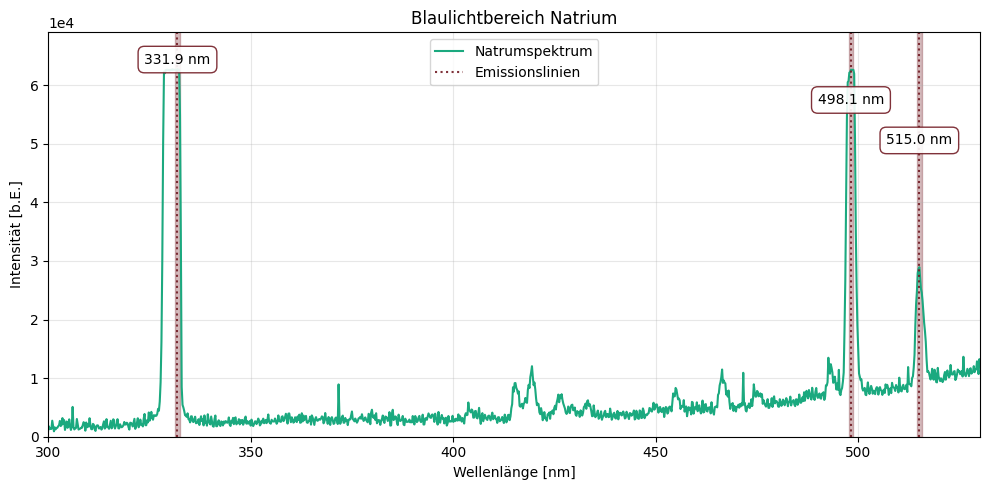

In [ ]:
aufgabe = '3b'
folder = './A3/'
safe_folder = '../img/A3/'

# ---------------------------------------------------------------------
# Daten vorbereiten
# ---------------------------------------------------------------------
df = main_peak

wavelength = df.iloc[:, 0].values
intensity = df.iloc[:, 1].values

# Bereich einschränken
x_min, x_max = 300, 530

mask = (wavelength >= x_min) & (wavelength <= x_max)

wl_cut = wavelength[mask]
int_cut = intensity[mask]

# Peaks nur im Bereich finden
peaks, properties = signal.find_peaks(
    int_cut,
    height=np.max(int_cut)*0.2,
    distance=10,
    prominence=0.2*np.max(int_cut),
)

peak_wavelengths = wl_cut[peaks]
peak_names = [f"{wl:.1f} nm" for wl in peak_wavelengths]

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    wavelength, 
    intensity, 
    color=hellgruen,
    label='Natrumspektrum'
    )

y_min, y_max = 0, np.max(intensity)*1.1

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

plot_lines_with_error(
    ax,
    peak_wavelengths,
    peak_names,
    err=0.6,
    y_min=y_min,
    y_max=y_max,
    b_label = True,
    color_err=weinrot,
    color_line=weinrot,
    label='Emissionslinien'
)

# ax.scatter(peak_wavelengths, int_cut[peaks], color='blue', zorder=3)
ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))

# ---------------------------------------------------------------------
# Beschriftung
# ---------------------------------------------------------------------
ax.set_xlabel("Wellenlänge [nm]")
ax.set_ylabel("Intensität [b.E.]")
ax.set_title("Blaulichtbereich Natrium")

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.savefig(f'{safe_folder}BL_Na_{aufgabe}.pdf')
plt.tight_layout()
plt.show()

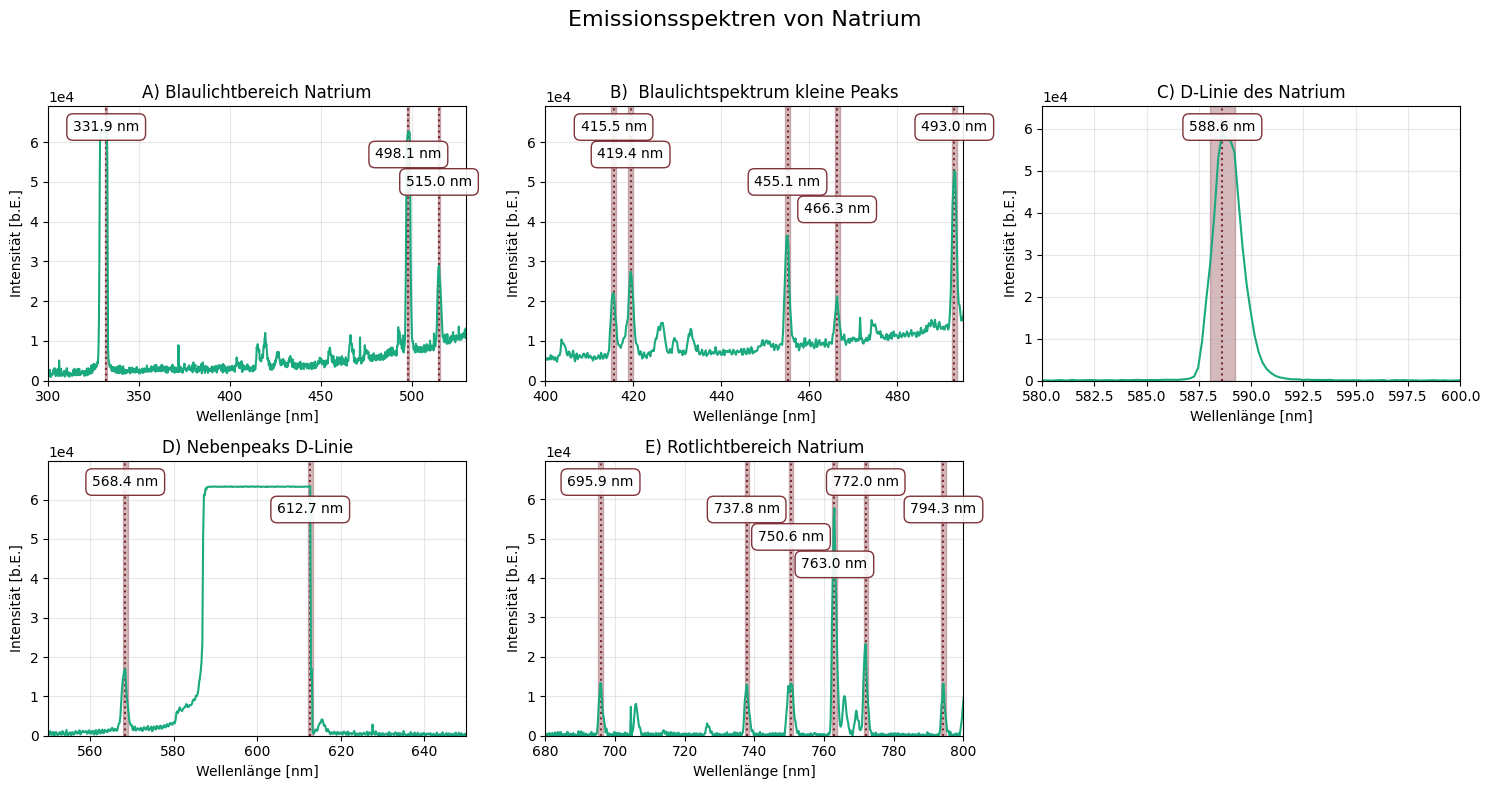

In [ ]:
aufgabe = '3b'
folder = './A3/'
safe_folder = '../img/A3/'

x_ranges = {
    'A) Blaulichtbereich Natrium': (300, 530),
    'B)  Blaulichtspektrum kleine Peaks': (400, 495),
    'C) D-Linie des Natrium': (580, 600),
    'D) Nebenpeaks D-Linie': (550, 650),
    'E) Rotlichtbereich Natrium': (680, 800),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Loop über alle Datensätze
for i, (title, df) in enumerate(datasets.items()):
    ax = axes[i]

    wavelength = df.iloc[:, 0].values
    intensity = df.iloc[:, 1].values

    # passenden Bereich holen
    x_min, x_max = x_ranges[title]
    mask = (wavelength >= x_min) & (wavelength <= x_max)

    wl_cut = wavelength[mask]
    int_cut = intensity[mask]

    # Peaks finden
    peaks, properties = signal.find_peaks(
        int_cut,
        height=np.max(int_cut)*0.2,
        distance=10,
        prominence=0.2*np.max(int_cut),
    )

    peak_wavelengths = wl_cut[peaks]
    peak_names = [f"{wl:.1f} nm" for wl in peak_wavelengths]


    y_min, y_max = 0, np.max(intensity)*1.1

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Peaks einzeichnen
    plot_lines_with_error(
        ax,
        peak_wavelengths,
        peak_names,
        err=0.6,
        y_min=y_min,
        y_max=y_max,
        b_label=True,
        color_err=weinrot,
        color_line=weinrot,
        label='Emissionslinien'
    )

    # Beschriftung
    ax.set_title(title)
    ax.set_xlabel("Wellenlänge [nm]")
    ax.set_ylabel("Intensität [b.E.]")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))
    
    # Plot Spektrum
    ax.plot(
        wavelength,
        intensity,
        color=hellgruen,
        label='Spektrum'
    )
# Leeres Feld entfernen
fig.delaxes(axes[5])

fig.suptitle("Emissionsspektren von Natrium", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{safe_folder}Na_Spektren_Grid_{aufgabe}.pdf')
plt.show()

In [244]:
peak_err = 1.2 # nm

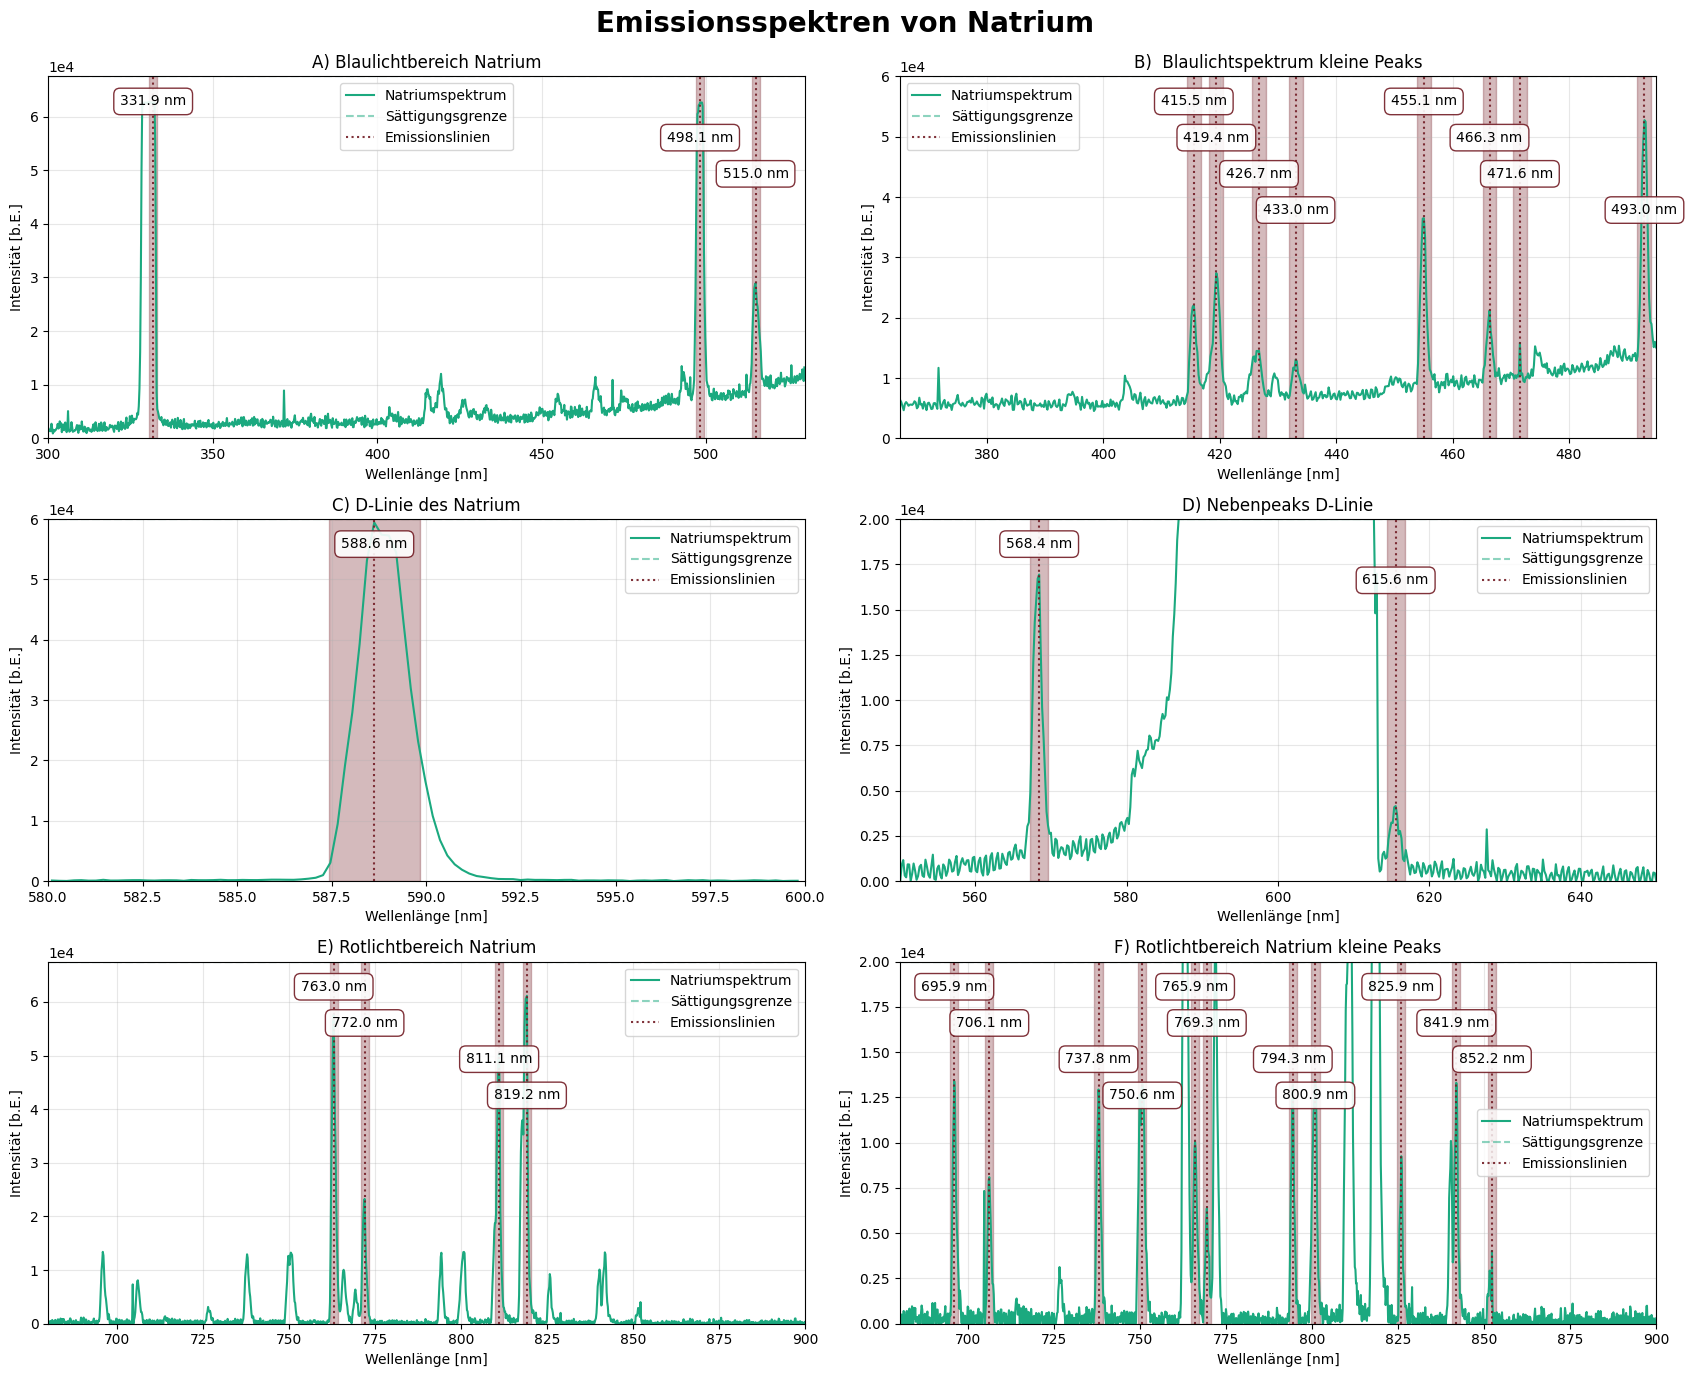

In [245]:
aufgabe = '3c'
folder = './A3/'
safe_folder = '../img/A3/'

fig, axes = plt.subplots(3, 2, figsize=(17, 14))
axes = axes.flatten()

x_ranges = {
    'A) Blaulichtbereich Natrium': (300, 530),
    'B)  Blaulichtspektrum kleine Peaks': (365, 495),
    'C) D-Linie des Natrium': (580, 600),
    'D) Nebenpeaks D-Linie': (550, 650),
    'E) Rotlichtbereich Natrium': (680, 900),
    'F) Rotlichtbereich Natrium kleine Peaks': (680, 900),
}

y_ranges = {
    'A) Blaulichtbereich Natrium': (0, 6.75e4),
    'B)  Blaulichtspektrum kleine Peaks': (0, 6e4),
    'C) D-Linie des Natrium': (0, 6e4),
    'D) Nebenpeaks D-Linie': (0, 2e4),
    'E) Rotlichtbereich Natrium': (0, 6.75e4),
    'F) Rotlichtbereich Natrium kleine Peaks': (0, 2e4),
}


datasets = {
    'A) Blaulichtbereich Natrium': main_peak, # Beriech 410 - 530 nm
    'B)  Blaulichtspektrum kleine Peaks': neben_peaks, # Beriech 410 - 530 nm
    'C) D-Linie des Natrium': D_line, # Beriech 550 - 650   nm
    'D) Nebenpeaks D-Linie': neben_D_line, # Beriech 550 - 650   nm
    'E) Rotlichtbereich Natrium': rot_Na,  # Beriech 650 - 800   nm
    'F) Rotlichtbereich Natrium kleine Peaks': rot_Na  # Beriech 650 - 800   nm
}

for i, (title, df) in enumerate(datasets.items()):
    ax = axes[i]  
    # y_cap_factor = 0.6

    # Daten vorbereiten
    wavelength = df.iloc[:, 0].values
    intensity = df.iloc[:, 1].values

    x_min, x_max = x_ranges[title]
    mask = (wavelength >= x_min) & (wavelength <= x_max)

    wl_cut = wavelength[mask]
    int_cut = intensity[mask]

    # y-Bereich 
    y_min, y_max = y_ranges[title]
    y_cap = y_max  # obere Achsengrenze

    # Peaks finden
    peaks, properties = signal.find_peaks(
        int_cut,
        height=0.2 * y_max,
        distance=10,
        prominence=0.1 * y_max,
    )

    # Peaks filtern
    valid = int_cut[peaks] <= y_max
    peaks = peaks[valid]

    peak_wavelengths = wl_cut[peaks]
    peak_names = [f"{wl:.1f} nm" for wl in peak_wavelengths]

    # Daten an Bereich anpassen
    int_cut_clipped = np.clip(int_cut, y_min, y_max)

    # Plot
    ax.plot(
        wl_cut,
        int_cut_clipped,
        color=hellgruen,
        label='Natriumspektrum'
    )

    # Sättigungslinie
    ax.axhline(
        y_max,
        color='gray',
        linestyle='--',
        alpha=0.5,
        # label='Sättigungsgrenze'
    )
    ax.axhline(
        y_cap,
        color=hellgruen,
        linestyle='--',
        alpha=0.5,
        label='Sättigungsgrenze'
    )

    peak_wavelengths = wl_cut[peaks]
    peak_names = [f"{wl:.1f} nm" for wl in peak_wavelengths]

    int_cut_clipped = np.clip(int_cut, 0, y_cap)

    y_min, y_max = 0, y_cap

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.ticklabel_format(axis='both', style='sci', scilimits=(0,4))

    # Peaks einzeichnen
    plot_lines_with_error(
        ax,
        peak_wavelengths,
        peak_names,
        err=peak_err,
        y_min=y_min,
        y_max=y_max,
        b_label=True,
        color_err=weinrot,
        color_line=weinrot,
        label='Emissionslinien'
    )

    ax.set_title(title)
    ax.set_xlabel("Wellenlänge [nm]")
    ax.set_ylabel("Intensität [b.E.]")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Emissionsspektren von Natrium", fontsize=20, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(f'{safe_folder}Na_Spektren_Grid_{aufgabe}.pdf')
plt.show()

In [246]:
rows = []

# Alphabetische Buchstaben für die Titel
letters = list(string.ascii_uppercase)

for i, (title, df) in enumerate(datasets.items()):
    # Peaks extrahieren
    peak_wavelengths = wl_cut[peaks]

    letter = letters[i % len(letters)] # 

    for j, wl in enumerate(peak_wavelengths):
        rows.append({
            "Bild": letter,
            "idx": j + 1,
            "Wellenlänge $\\lambda$ [nm]": f"${wl:.1f} \\pm 0.6$"
        })

df_latex = pd.DataFrame(rows)

# Leere Zellen für wiederholte Buchstaben
df_latex["Bild"] = df_latex["Bild"].mask(df_latex["Bild"].duplicated(), "")

# longtable für mehrseitige Tabellen
latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format="l | c | c",
    longtable=True,
    caption='Gemessene Emissionslinen der Natriumlampe'
)

print(latex_table)

\begin{longtable}{l | c | c}
\caption{Gemessene Emissionslinen der Natriumlampe} \\
\toprule
Bild & idx & Wellenlänge $\lambda$ [nm] \\
\midrule
\endfirsthead
\caption[]{Gemessene Emissionslinen der Natriumlampe} \\
\toprule
Bild & idx & Wellenlänge $\lambda$ [nm] \\
\midrule
\endhead
\midrule
\multicolumn{3}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
A & 1 & $695.9 \pm 0.6$ \\
 & 2 & $706.1 \pm 0.6$ \\
 & 3 & $737.8 \pm 0.6$ \\
 & 4 & $750.6 \pm 0.6$ \\
 & 5 & $765.9 \pm 0.6$ \\
 & 6 & $769.3 \pm 0.6$ \\
 & 7 & $794.3 \pm 0.6$ \\
 & 8 & $800.9 \pm 0.6$ \\
 & 9 & $825.9 \pm 0.6$ \\
 & 10 & $841.9 \pm 0.6$ \\
 & 11 & $852.2 \pm 0.6$ \\
B & 1 & $695.9 \pm 0.6$ \\
 & 2 & $706.1 \pm 0.6$ \\
 & 3 & $737.8 \pm 0.6$ \\
 & 4 & $750.6 \pm 0.6$ \\
 & 5 & $765.9 \pm 0.6$ \\
 & 6 & $769.3 \pm 0.6$ \\
 & 7 & $794.3 \pm 0.6$ \\
 & 8 & $800.9 \pm 0.6$ \\
 & 9 & $825.9 \pm 0.6$ \\
 & 10 & $841.9 \pm 0.6$ \\
 & 11 & $852.2 \pm 0.6$ \\
C & 1 & $695.9 \pm 0.6$ \\
 & 2 & $706

In [247]:
# Beispiel-Daten
datasets = {
    "A": pd.DataFrame({"wl": [589.0, 589.6]}),
    "B": pd.DataFrame({"wl": [590.0, 591.0]}),
    "C": pd.DataFrame({"wl": [592.0]}),
    "D": pd.DataFrame({"wl": [593.0, 593.5, 594.0]}),
    "E": pd.DataFrame({"wl": [595.0]}),
    "F": pd.DataFrame({"wl": [596.0, 596.5]})
}

letters = list(string.ascii_uppercase)
all_rows = []

# Alle Reihen in einheitliches Format bringen
for i, (title, df) in enumerate(datasets.items()):
    letter = letters[i]
    peaks = df['wl']  
    for j, wl in enumerate(peaks):
        all_rows.append({"Bild": letter, "idx": j + 1, "Wellenlänge": f"${wl:.1f} \\pm 0.6$"})

# Jetzt die Daten in 3-Spalten-Layout transformieren
# Wir erstellen ein Dictionary mit einer Liste pro Messreihe
groups = {}
for letter in letters[:6]:
    groups[letter] = [r for r in all_rows if r["Bild"] == letter]

# Bestimme die maximale Länge pro Gruppe
max_len = max(len(v) for v in groups.values())

# Leere Listen auffüllen, damit jede Spalte die gleiche Länge hat
for k, v in groups.items():
    while len(v) < max_len:
        v.append({"Bild": "", "idx": "", "Wellenlänge": ""})

# Jetzt drei nebeneinander
columns_order = [("A","B","C"), ("D","E","F")]
final_rows = []
for trio in columns_order:
    for i in range(max_len):
        row = []
        for letter in trio:
            row.extend([groups[letter][i]["Bild"], groups[letter][i]["idx"], groups[letter][i]["Wellenlänge"]])
        final_rows.append(row)

# DataFrame für LaTeX erstellen
column_names = []
for trio in columns_order[0]:  # Spaltennamen nur einmal setzen
    column_names.extend([f"Bild", "idx", "Wellenlänge $\\lambda$ [nm]"])

# DataFrame
df_latex = pd.DataFrame(final_rows, columns=[
    "Bild", "idx", "Wellenlänge $\\lambda$ [nm]",
    "Bild", "idx", "Wellenlänge $\\lambda$ [nm]",
    "Bild", "idx", "Wellenlänge $\\lambda$ [nm]",
])

# LaTeX-Tabelle
latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format="l c c | l c c | l c c",
    longtable=True,
    caption='Gemessene Emissionslinien der Natriumlampe'
)

print(latex_table)

\begin{longtable}{l c c | l c c | l c c}
\caption{Gemessene Emissionslinien der Natriumlampe} \\
\toprule
Bild & idx & Wellenlänge $\lambda$ [nm] & Bild & idx & Wellenlänge $\lambda$ [nm] & Bild & idx & Wellenlänge $\lambda$ [nm] \\
\midrule
\endfirsthead
\caption[]{Gemessene Emissionslinien der Natriumlampe} \\
\toprule
Bild & idx & Wellenlänge $\lambda$ [nm] & Bild & idx & Wellenlänge $\lambda$ [nm] & Bild & idx & Wellenlänge $\lambda$ [nm] \\
\midrule
\endhead
\midrule
\multicolumn{9}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
A & 1 & $589.0 \pm 0.6$ & B & 1 & $590.0 \pm 0.6$ & C & 1 & $592.0 \pm 0.6$ \\
A & 2 & $589.6 \pm 0.6$ & B & 2 & $591.0 \pm 0.6$ &  &  &  \\
 &  &  &  &  &  &  &  &  \\
D & 1 & $593.0 \pm 0.6$ & E & 1 & $595.0 \pm 0.6$ & F & 1 & $596.0 \pm 0.6$ \\
D & 2 & $593.5 \pm 0.6$ &  &  &  & F & 2 & $596.5 \pm 0.6$ \\
D & 3 & $594.0 \pm 0.6$ &  &  &  &  &  &  \\
\end{longtable}



In [248]:
# # Peaks sammeln für die Tabelle
# letters = list(string.ascii_uppercase)
# all_rows = []

# for i, (title, df) in enumerate(datasets.items()):
#     wavelength = df.iloc[:, 0].values
#     intensity = df.iloc[:, 1].values

#     x_min, x_max = x_ranges[title]
#     mask = (wavelength >= x_min) & (wavelength <= x_max)

#     wl_cut = wavelength[mask]
#     int_cut = intensity[mask]
    
#     y_min, y_max = y_ranges[title]

#     # Peaks finden
#     peaks, properties = signal.find_peaks(
#         int_cut,
#         height=0.2 * y_max,
#         distance=10,
#         prominence=0.1 * y_max,
#     )

#     # Peaks filtern
#     valid = int_cut[peaks] <= y_max
#     peaks = peaks[valid]

#     peak_wavelengths = wl_cut[peaks]

#     letter = letters[i]  # A-F

#     for j, wl in enumerate(peak_wavelengths):
#         all_rows.append({"Bild": letter, "idx": j + 1, "Wellenlänge": f"${wl:.1f} \\pm 0.6$"})

# # 3-Spalten-Layout
# groups = {}
# for letter in letters[:6]:
#     groups[letter] = [r for r in all_rows if r["Bild"] == letter]

# max_len = max(len(v) for v in groups.values())

# # Auffüllen mit leeren Einträgen
# for k, v in groups.items():
#     while len(v) < max_len:
#         v.append({"Bild": "", "idx": "", "Wellenlänge": ""})

# columns_order = [("A","B","C"), ("D","E","F")]
# final_rows = []

# for trio in columns_order:
#     for i in range(max_len):
#         row = []
#         for letter in trio:
#             row.extend([groups[letter][i]["Bild"], groups[letter][i]["idx"], groups[letter][i]["Wellenlänge"]])
#         final_rows.append(row)

# df_latex = pd.DataFrame(final_rows, columns=[
#     "Bild", "idx", "Wellenlänge $\\lambda$ [nm]",
#     "Bild", "idx", "Wellenlänge $\\lambda$ [nm]",
#     "Bild", "idx", "Wellenlänge $\\lambda$ [nm]",
# ])

# # LaTeX-Tabelle erzeugen
# latex_table = df_latex.to_latex(
#     index=False,
#     escape=False,
#     column_format="l | c | c || l | c | c || l | c | c ",
#     longtable=True,
#     caption='Gemessene Emissionslinien der Natriumlampe'
# )

# print(latex_table)

## Berechnung der 1. Neben Serie

In [539]:
hc_val = 1239.8 # nm eV
E_ry = -13.605 # eV

In [540]:
E_Ry_sym, lam_E4_sym, m_sym, hc_sym = sp.symbols(r'{E_\text{Ry}}, {\lambda_\text{E4}}, m, {hc}')
params = [E_Ry_sym, lam_E4_sym, m_sym, hc_sym]

E_drei_P_func = (E_Ry_sym/m_sym**2) - (hc_sym / lam_E4_sym)

values = np.array([
    E_ry,
    819.2, peak_err,
    3,
    hc_val
])

res = calc2(E_drei_P_func, params, values, [E_Ry_sym, m_sym, hc_sym], p_latex=False)
E_drei_P_val = res[0][0]
E_drei_P_err = res[0][1]

round_sig_digs(E_drei_P_val, E_drei_P_err)[2]

Results:
[[-3.02509440e+00  2.21693516e-03]]


'-3.025 \\pm 0.0022'

In [541]:
E_Ry_sym, E_3p_sym, m_sym, hc_sym = sp.symbols(r'{E_\text{Ry}}, {E_\text{3p}}, m, {hc}')
params = [E_Ry_sym, E_3p_sym, m_sym, hc_sym]

lam_n1_func = hc_sym / (E_Ry_sym / m_sym**2 - E_3p_sym)

m_steps = np.arange(4,13)

values = [
    E_ry,
    E_drei_P_val, E_drei_P_err,
    m_steps,
    hc_val
]

res = calc2(lam_n1_func, params, values, [E_Ry_sym, m_sym, hc_sym], p_latex=False)
lam_n1_val = res[:,0]
lam_n1_err = res[:,1]
print(lam_n1_val)
print(lam_n1_err)

Results:
[[5.70080154e+02 5.81129875e-01]
 [4.99739126e+02 4.46568479e-01]
 [4.68347850e+02 3.92227844e-01]
 [4.51256222e+02 3.64122709e-01]
 [4.40815227e+02 3.47467776e-01]
 [4.33931734e+02 3.36700827e-01]
 [4.29138437e+02 3.29303381e-01]
 [4.25659548e+02 3.23985906e-01]
 [4.23051100e+02 3.20027292e-01]]
[570.08015351 499.73912613 468.34784983 451.2562223  440.81522676
 433.93173428 429.13843745 425.65954796 423.05110048]
[0.58112988 0.44656848 0.39222784 0.36412271 0.34746778 0.33670083
 0.32930338 0.32398591 0.32002729]


Dazugehörende Linien in gleicher Reihenfolge:
1. B7
2. A2
3. B6
4. B5
5. -- 
6. B4
7. --
8. B3
9. --

In [542]:
theo_lambda_N1 = lam_n1_val
theo_N1_err = lam_n1_err

exp_lambda_N1 = np.array([
    568.4,  # D1
    498.1,  # A2
    466.3,  # B6
    455.1,  # B5
    np.nan,  # --
    433.0,  # B4
    np.nan,  # --
    426.7,  # B3
    np.nan  # --
])

exp_err = peak_err

# Index / Linienbezeichnungen
idx = ["B7", "A2", "B6", "B5", "--", "B4", "--", "B3", "--"]

# Standardabweichung berechnen (nur wo exp vorhanden)
sigma = abs(exp_lambda_N1 - theo_lambda_N1) / np.sqrt(theo_N1_err**2 + exp_err**2)

theo_res = []
exp_res = []
for i in range(len(theo_lambda_N1)):
    theo_res.append(f'${theo_lambda_N1[i]:.1f} \\pm {theo_N1_err[i]:.1f}$')
    exp_res.append(f'${exp_lambda_N1[i]} \\pm {exp_err}$')

df = pd.DataFrame({
    "m": m_steps,
    r"$\lambda_{\text{N1}}$ [nm]": theo_res,
    r"$\lambda_{\text{exp}}$ [nm]": exp_res,
    "Idx": idx,
    r"$\sigma$": sigma
})


latex_table = df.to_latex(
    index=False,
    na_rep="",
    float_format="%.2f",
    caption="Vergleich von theoretischen und experimentellen Wellenlängen der N1-Serie",
    label="tab:n1_lambdas"
)

print(latex_table)

\begin{table}
\caption{Vergleich von theoretischen und experimentellen Wellenlängen der N1-Serie}
\label{tab:n1_lambdas}
\begin{tabular}{rlllr}
\toprule
m & $\lambda_{\text{N1}}$ [nm] & $\lambda_{\text{exp}}$ [nm] & Idx & $\sigma$ \\
\midrule
4 & $570.1 \pm 0.6$ & $568.4 \pm 1.2$ & B7 & 1.26 \\
5 & $499.7 \pm 0.4$ & $498.1 \pm 1.2$ & A2 & 1.28 \\
6 & $468.3 \pm 0.4$ & $466.3 \pm 1.2$ & B6 & 1.62 \\
7 & $451.3 \pm 0.4$ & $455.1 \pm 1.2$ & B5 & 3.07 \\
8 & $440.8 \pm 0.3$ & $nan \pm 1.2$ & -- &  \\
9 & $433.9 \pm 0.3$ & $433.0 \pm 1.2$ & B4 & 0.75 \\
10 & $429.1 \pm 0.3$ & $nan \pm 1.2$ & -- &  \\
11 & $425.7 \pm 0.3$ & $426.7 \pm 1.2$ & B3 & 0.84 \\
12 & $423.1 \pm 0.3$ & $nan \pm 1.2$ & -- &  \\
\bottomrule
\end{tabular}
\end{table}



## Zweite Nebenserie

In [543]:
E_3p_sym, hc_sym, lam_D_sym = sp.symbols(r'{E_\text{3p}}, {hc}, {\lambda_D}')
params = [E_3p_sym, hc_sym, lam_D_sym]

E_drei_s_func = E_3p_sym - (hc_sym / lam_D_sym)

m_steps = np.arange(4,13)

values = [
    E_drei_P_val, E_drei_P_err,
    hc_val,
    588.6, 1.2
]

res = calc2(E_drei_s_func, params, values, [hc_sym], p_latex=False)
E_drei_s_val = res[:,0][0]
E_drei_s_err = res[:,1][0]
print(f'{E_drei_s_val:.3f}')
print(f'{E_drei_s_err:.1g}')

Results:
[[-5.13144846e+00  4.83278516e-03]]
-5.131
0.005


In [544]:
# Korrektursfaktor N2
N2_korr_val = 3 - np.sqrt(E_ry/E_drei_s_val)
korr_N2_err = 0.5 * np.sqrt(E_ry/E_drei_s_val**3) * E_drei_s_err

print(f'Korrekturstherm: {N2_korr_val:.4f} \\pm {korr_N2_err:.1g}')

Korrekturstherm: 1.3717 \pm 0.0008


In [545]:
E_Ry_sym, E_3p_sym, m_sym, hc_sym, delta_sym = sp.symbols(r'{E_\text{Ry}}, {E_\text{3p}}, m, {hc}, {\delta_s}')
params = [E_Ry_sym, E_3p_sym, m_sym, hc_sym, delta_sym]

lam_n2_func = hc_sym / (E_Ry_sym / (m_sym - delta_sym)**2 - E_3p_sym)

m_steps = np.arange(4,10)

values = [
    E_ry,
    E_drei_P_val, E_drei_P_err,
    m_steps,
    hc_val,
    N2_korr_val, korr_N2_err
]

res = calc2(lam_n2_func, params, values, [E_Ry_sym, m_sym, hc_sym], p_latex=False)
lam_n2_val = res[:,0]
lam_n2_err = res[:,1]
# print(lam_n2_val)
# print(lam_n2_err)

Results:
[[1.17449937e+03 2.77832382e+00]
 [6.22506119e+02 7.06250603e-01]
 [5.18751395e+02 4.83356704e-01]
 [4.77652588e+02 4.08535499e-01]
 [4.56576595e+02 3.72954038e-01]
 [4.44166752e+02 3.52850739e-01]]


--, D2, A3, B7, B5, --

wichtig: B5 wurde auch bei 1. NS  benutzt!!

In [546]:
theo_lambda_N2 = lam_n2_val
theo_N2_err = lam_n2_err

exp_lambda_N2 = np.array([
    np.nan,  # --
    615.6,  # D2
    515.0,  # A3
    471.6,  # B7
    455.1,  # B5
    np.nan,  # --
])

exp_err = peak_err

# Index / Linienbezeichnungen
idx = ['--', 'D2', 'A3', 'B7', 'B5', '--']

# Standardabweichung berechnen (nur wo exp vorhanden)
sigma = abs(exp_lambda_N2 - theo_lambda_N2) / np.sqrt(theo_N2_err**2 + exp_err**2)

theo_res = []
exp_res = []
for i in range(len(theo_lambda_N2)):
    theo_res.append(f'${theo_lambda_N2[i]:.1f} \\pm {theo_N2_err[i]:.1f}$')
    exp_res.append(f'${exp_lambda_N2[i]} \\pm {exp_err}$')

df = pd.DataFrame({
    "m": m_steps,
    r"$\lambda_{\text{N2}}$ [nm]": theo_res,
    r"$\lambda_{\text{exp}}$ [nm]": exp_res,
    "Idx": idx,
    r"Std. Abw. $\sigma$": sigma
})


latex_table = df.to_latex(
    index=False,
    na_rep="",
    float_format="%.2f",
    caption="Vergleich von theoretischen und experimentellen Wellenlängen der N2-Serie",
    label="tab:n2_lambdas",
    column_format='r | c c | l || c'
)

print(latex_table)

\begin{table}
\caption{Vergleich von theoretischen und experimentellen Wellenlängen der N2-Serie}
\label{tab:n2_lambdas}
\begin{tabular}{r | c c | l || c}
\toprule
m & $\lambda_{\text{N2}}$ [nm] & $\lambda_{\text{exp}}$ [nm] & Idx & Std. Abw. $\sigma$ \\
\midrule
4 & $1174.5 \pm 2.8$ & $nan \pm 1.2$ & -- &  \\
5 & $622.5 \pm 0.7$ & $615.6 \pm 1.2$ & D2 & 4.96 \\
6 & $518.8 \pm 0.5$ & $515.0 \pm 1.2$ & A3 & 2.90 \\
7 & $477.7 \pm 0.4$ & $471.6 \pm 1.2$ & B7 & 4.77 \\
8 & $456.6 \pm 0.4$ & $455.1 \pm 1.2$ & B5 & 1.18 \\
9 & $444.2 \pm 0.4$ & $nan \pm 1.2$ & -- &  \\
\bottomrule
\end{tabular}
\end{table}



## Hauptserie

In [547]:
# Korrektursfaktor Haupt
HS_korr_val = 3 - np.sqrt(E_ry/E_drei_P_val)
HS_korr_err = 0.5 * np.sqrt(E_ry/E_drei_P_val**3) * E_drei_P_err

print(f'Korrekturstherm: {HS_korr_val:.4f} \\pm {HS_korr_err:.1g}')

Korrekturstherm: 0.8793 \pm 0.0008


In [548]:
E_Ry_sym, E_3s_sym, m_sym, hc_sym, delta_sym = sp.symbols(r'{E_\text{Ry}}, {E_\text{3s}}, m, {hc}, {\delta_p}')
params = [E_Ry_sym, E_3s_sym, m_sym, hc_sym, delta_sym]

lam_HS_func = hc_sym / (E_Ry_sym / (m_sym - delta_sym)**2 - E_3s_sym)

m_steps = np.arange(4,6)

values = [
    E_ry,
    E_drei_s_val, E_drei_s_err,
    m_steps,
    hc_val,
    HS_korr_val, HS_korr_err
]

res = calc2(lam_HS_func, params, values, [E_Ry_sym, m_sym, hc_sym], p_latex=False)
lam_HS_val = res[:,0]
lam_HS_err = res[:,1]
# print(lam_HS_val)
# print(lam_HS_err)

Results:
[[3.31989356e+02 4.34058594e-01]
 [2.86313348e+02 3.20166884e-01]]


In [549]:
theo_lambda_HS = lam_HS_val
theo_err_HS = lam_HS_err

exp_lambda_HS = np.array([
    331.9,  # A1
    np.nan,  # --
])

exp_err = peak_err

# Index / Linienbezeichnungen
idx = ['A1', '--']

# Standardabweichung berechnen (nur wo exp vorhanden)
sigma = abs(exp_lambda_HS - theo_lambda_HS) / np.sqrt(theo_err_HS**2 + exp_err**2)

theo_res = []
exp_res = []
for i in range(len(theo_lambda_HS)):
    theo_res.append(f'${theo_lambda_HS[i]:.1f} \\pm {theo_err_HS[i]:.1f}$')
    exp_res.append(f'${exp_lambda_HS[i]} \\pm {exp_err}$')

df = pd.DataFrame({
    "m": m_steps,
    r"$\lambda_{\text{N2}}$ [nm]": theo_res,
    r"$\lambda_{\text{exp}}$ [nm]": exp_res,
    "Idx": idx,
    r"Std. Abw. $\sigma$": sigma
})


latex_table = df.to_latex(
    index=False,
    na_rep="",
    float_format="%.2f",
    caption="Vergleich von theoretischen und experimentellen Wellenlängen der N2-Serie",
    label="tab:n2_lambdas",
    column_format='r | c c | l || c'
)

print(latex_table)

\begin{table}
\caption{Vergleich von theoretischen und experimentellen Wellenlängen der N2-Serie}
\label{tab:n2_lambdas}
\begin{tabular}{r | c c | l || c}
\toprule
m & $\lambda_{\text{N2}}$ [nm] & $\lambda_{\text{exp}}$ [nm] & Idx & Std. Abw. $\sigma$ \\
\midrule
4 & $332.0 \pm 0.4$ & $331.9 \pm 1.2$ & A1 & 0.07 \\
5 & $286.3 \pm 0.3$ & $nan \pm 1.2$ & -- &  \\
\bottomrule
\end{tabular}
\end{table}



# Aufgabe 4) Serienenergien der Nebenserien

In [637]:
# Definition der Linearen Regression
def fit_func(m, E_Ry, E_3p, delta_d):
    return hc_val/(E_Ry/(m - delta_d)**2 - E_3p)
vals = [E_ry, E_drei_P_val, HS_korr_err]

m_steps = np.arange(3,13)

# m = 3 hinzufügen
exp_lambda_N1_full = np.append(819.2, exp_lambda_N1)

# Leere Werte Entfernen
exp_lambda_N1_noNaN = exp_lambda_N1_full[~np.isnan(exp_lambda_N1_full)]
m_steps_korr = m_steps[~np.isnan(exp_lambda_N1_full)]

popt, pcov = curve_fit(fit_func, m_steps_korr, exp_lambda_N1_noNaN, sigma=1 ,p0=vals)

print(f"E_Ry = {popt[0]:.1f} \\pm {np.sqrt(pcov[0][0]):.1g}")
print(f"E_3p = {popt[1]:.3f} \\pm {np.sqrt(pcov[1][1]):.2g}")
print(f"delta_d = {popt[2]:.2f} \\pm {np.sqrt(pcov[2][2]):.1g}")

E_Ry = -12.7 \pm 0.8
E_3p = -3.012 \pm 0.014
delta_d = 0.09 \pm 0.08


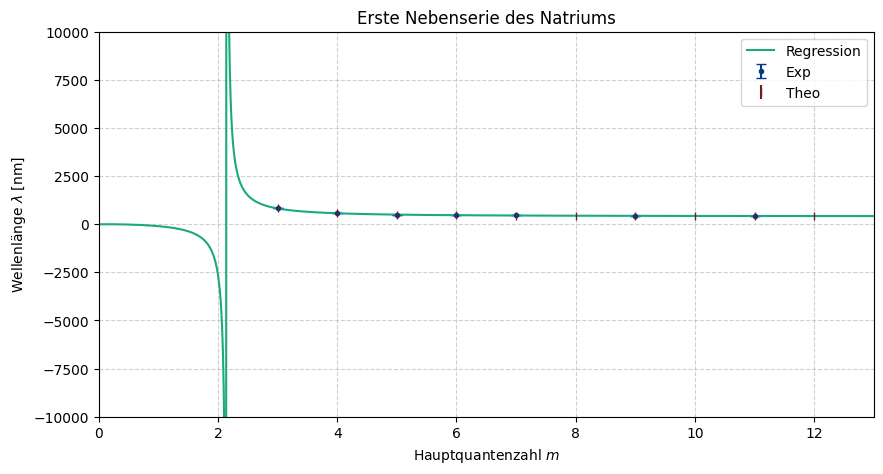

In [638]:
aufgabe = '4z'
safe_folder ='../img/A4/'

# Parameter + Fehler
E_Ry_fit, E_3p_fit, delta_d_fit = popt
E_Ry_err = np.sqrt(pcov[0][0])
E_3p_err = np.sqrt(pcov[1][1])
delta_d_err = np.sqrt(pcov[2][2])

theo_lambda_N1_Full = np.append(819, theo_lambda_N1)

# Text für Plot
fit_text = (
    f"$E_{{Ry}} = {E_Ry_fit:.1f} \\pm {E_Ry_err:.1g}$\n"
    f"$E_{{3p}} = {E_3p_fit:.3f} \\pm {E_3p_err:.2g}$\n"
    f"$\\delta_d = {delta_d_fit:.2f} \\pm {delta_d_err:.1g}$"
)

# Glatte Fit-Kurve
m_fine = np.linspace(0, 13, 1000)
fit_curve = fit_func(m_fine, *popt)

plt.figure(figsize=(10,5))

# --- Plot ---
plt.errorbar(
    m_steps_korr, 
    exp_lambda_N1_noNaN,
    1.2,
    None,
    capsize=3.5,
    label="Exp", 
    color=blau,
    linestyle='',
    fmt='.'
    )

plt.plot(
    m_fine, 
    fit_curve, 
    label="Regression", 
    color=hellgruen
    )

theo_N1_err_full = np.append(0, theo_N1_err) 

plt.errorbar(
    m_steps, 
    theo_lambda_N1_Full, 
    theo_N1_err_full,
    None,
    label="Theo", 
    color=weinrot,
    linestyle='',
    fmt='|'
    )

plt.xlim(0, 13)
plt.ylim(-10000, 10000)
plt.xlabel("Hauptquantenzahl $m$")
plt.ylabel("Wellenlänge $\\lambda$ [nm]")
plt.title("Erste Nebenserie des Natriums")
plt.legend()
# plt.text(10.2,750, fit_text, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
plt.grid(True, linestyle="--", alpha=0.6)
# plt.tight_layout()
plt.savefig(f'{safe_folder}N1_{aufgabe}.pdf', dpi = 300)
plt.show()

In [639]:
# Abweichung
print(f'Std.Abw. E_ry_1: {sigma_abweichung(E_ry, E_Ry_fit, E_Ry_err)}')

print(f'Std.Abw. E_3p: {sigma_abweichung(E_drei_P_val, E_3p_fit, E_drei_P_err, E_3p_err)}')

Std.Abw. E_ry_1: 1.15
Std.Abw. E_3p: 0.9


In [640]:
# Bestimmen der X^2 Summe

Delta_lam = 2 * peak_err
Delta_lam = peak_err


chi_sq = np.sum((fit_func(m_steps_korr,*popt) - exp_lambda_N1_noNaN)**2/Delta_lam**2)
deg_free=len(m_steps)-(len(m_steps) - len(m_steps_korr))
chi_sq_red=chi_sq/deg_free
print(f"chi_sq = {chi_sq:.2f}")
print(f"chi_sq_red = {chi_sq_red:.2f}")

prob=(1-chi2.cdf(chi_sq,deg_free))*100
print(f"Wahrscheinlichkeit: {prob:.2f} %")

chi_sq = 13.75
chi_sq_red = 1.96
Wahrscheinlichkeit: 5.58 %


## Zweite Nebenserie

In [641]:
# Definition der Linearen Regression
def fit_func(m, E_Ry, E_3p, delta_s):
    return hc_val/(E_Ry/(m - delta_s)**2 - E_3p)
vals = [E_ry, E_drei_P_val, N2_korr_val]


m_steps = np.arange(4,10)

# Leere Werte Entfernen
exp_lambda_N2_noNaN = exp_lambda_N2[~np.isnan(exp_lambda_N2)]
m_steps_korr = m_steps[~np.isnan(exp_lambda_N2)]

popt, pcov = curve_fit(fit_func, m_steps_korr, exp_lambda_N2_noNaN, sigma=1 ,p0=vals)

print(f"E_Ry = {popt[0]:.0f} \\pm {np.sqrt(pcov[0][0]):.0f}")
print(f"E_3p = {popt[1]:.2f} \\pm {np.sqrt(pcov[1][1]):.1g}")
print(f"delta_d = {popt[2]:.1f} \\pm {np.sqrt(pcov[2][2]):.1g}")

E_Ry = -13 \pm 5
E_3p = -3.03 \pm 0.07
delta_d = 1.5 \pm 0.5


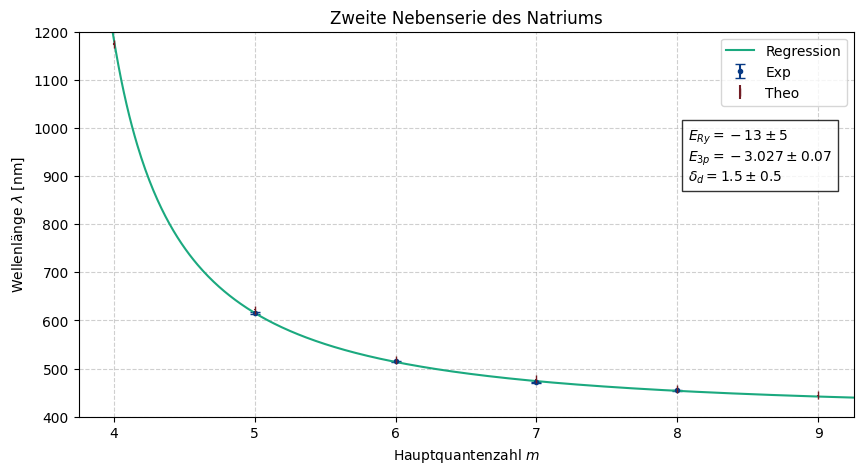

In [642]:
aufgabe = '4b'
safe_folder ='../img/A4/'

# Parameter + Fehler
E_Ry_fit_2, E_3p_fit_2, delta_d_fit_2 = popt
E_Ry_err_2 = np.sqrt(pcov[0][0])
E_3p_err_2 = np.sqrt(pcov[1][1])
delta_s_err_2 = np.sqrt(pcov[2][2])

# Text für Plot
fit_text = (
    f"$E_{{Ry}} = {E_Ry_fit_2:.0f} \\pm {E_Ry_err_2:.0g}$\n"
    f"$E_{{3p}} = {E_3p_fit_2:.3f} \\pm {E_3p_err_2:.1g}$\n"
    f"$\\delta_d = {delta_d_fit_2:.1f} \\pm {delta_s_err_2:.1g}$"
)

# Glatte Fit-Kurve
m_fine = np.linspace(2.75, 12.25, 1000)
fit_curve = fit_func(m_fine, *popt)

plt.figure(figsize=(10,5))

# --- Plot ---
plt.errorbar(
    m_steps_korr, 
    exp_lambda_N2_noNaN,
    1.2,
    None,
    capsize=3.5,
    label="Exp", 
    color=blau,
    linestyle='',
    fmt='.'
    )

plt.plot(
    m_fine, 
    fit_curve, 
    label="Regression", 
    color=hellgruen
    )

# theo_N2_err_full = np.append(0, theo_N2_err) 

plt.errorbar(
    m_steps, 
    theo_lambda_N2, 
    theo_N2_err,
    None,
    label="Theo", 
    color=weinrot,
    linestyle='',
    fmt='|'
    )

plt.xlim(3.75, 9.25)
plt.ylim(400, 1200)
plt.xlabel("Hauptquantenzahl $m$")
plt.ylabel("Wellenlänge $\\lambda$ [nm]")
plt.title("Zweite Nebenserie des Natriums")
plt.legend()
plt.text(8.075,1000, fit_text, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))
plt.grid(True, linestyle="--", alpha=0.6)
# plt.tight_layout()
plt.savefig(f'{safe_folder}N2_{aufgabe}.pdf', dpi = 300)
plt.show()

In [ ]:
# Abweichung
print(f'Std.Abw. Lit zu E_ry_2: {sigma_abweichung(E_ry, E_Ry_fit_2, E_Ry_err_2)}')

print(f'Std.Abw. Lit zu E_3p_2: {sigma_abweichung(E_drei_P_val, E_3p_fit_2, E_drei_P_err, E_3p_err_2)}')

print(f'Std.Abw. E_3p_1 zu E_3p_2: {sigma_abweichung(E_3p_fit, E_3p_fit_2, E_3p_err, E_3p_err_2)}')

print(f'Std.Abw. delta_s1 zu delta_s2: {sigma_abweichung(delta_d_fit_2, 1.3717, delta_s_err_2, 0.0008)}')

print(f'Std.Abw. E_ry_1 zu E_ry_2: {sigma_abweichung(E_Ry_fit_2, E_Ry_fit, E_Ry_err_2, E_Ry_err)}')


Std.Abw. Lit zu E_ry_2: 0.24
Std.Abw. Lit zu E_3p_2: 0.03
Std.Abw. E_3p_1 zu E_3p_2: 0.2
Std.Abw. E_3p_1 zu E_3p_2: 0.22


In [644]:
# Bestimmen der X^2 Summe

Delta_lam = 2 * peak_err
Delta_lam = peak_err


chi_sq = np.sum((fit_func(m_steps_korr,*popt) - exp_lambda_N2_noNaN)**2/Delta_lam**2)
deg_free=len(m_steps)-(len(m_steps) - len(m_steps_korr))
chi_sq_red=chi_sq/deg_free
print(f"chi_sq = {chi_sq:.2f}")
print(f"chi_sq_red = {chi_sq_red:.2f}")

prob=(1-chi2.cdf(chi_sq,deg_free))*100
print(f"Wahrscheinlichkeit: {prob:.2f} %")

chi_sq = 6.26
chi_sq_red = 1.57
Wahrscheinlichkeit: 18.03 %
